# Fly connectome bimodularity
Reproduces the bimodularity-style experiments from the `Bimodularity-Figures` notebook on the fly connectome (`connections_princeton.csv`). The notebook builds a directed weighted graph, computes a directed modularity matrix, performs SVD, clusters edges into bicommunities, and visualizes the resulting sending/receiving communities with rich plots.


In [34]:
import sys
print("Notebook python:", sys.executable)
!{sys.executable} -m pip install -U pip
!{sys.executable} -m pip install -U scikit-learn

Notebook python: /home/klrshak/miniconda3/envs/bimodularity/bin/python


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pathlib import Path
from sklearn.cluster import KMeans
from matplotlib.gridspec import GridSpec

sns.set_context('talk')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlepad'] = 12


In [36]:
DATA_DIR = Path('../data/raw')
CONNECTIONS_PATH = DATA_DIR / 'connections_princeton.csv'
ANNOTATIONS_PATH = DATA_DIR / 'classification.csv'

N_CLUSTERS = 6
N_VECTORS = 6
TOP_N_NODES = 10000  # adjust to control size; increase for richer structure if resources allow
EDGE_WEIGHT_COL = 'syn_count'

assert CONNECTIONS_PATH.exists(), 'connections_princeton.csv missing'
CONNECTIONS_PATH
assert ANNOTATIONS_PATH.exists(), 'classification.csv.gz missing'
ANNOTATIONS_PATH
FOCUS_PN_KC_MBON = True
MIN_SYN = 5

In [37]:
connections = pd.read_csv(CONNECTIONS_PATH)
connections = connections[['pre_root_id', 'post_root_id', EDGE_WEIGHT_COL, 'neuropil', 'nt_type']]
connections.head()


,pre_root_id,post_root_id,syn_count,neuropil,nt_type
0,720575940625363947,720575940623224444,12,ME_L,GABA
1,720575940630432382,720575940618518557,67,ME_L,ACH
2,720575940627314521,720575940626337738,10,ME_L,GABA
3,720575940620280405,720575940620204726,15,ME_L,ACH
4,720575940636942447,720575940613789411,1,LA_L,GLUT


In [38]:
ann = pd.read_csv(ANNOTATIONS_PATH)  # works with .csv.gz
ann.columns = [c.strip() for c in ann.columns]

# Quick sanity: see what columns exist
print("Annotation columns:", ann.columns.tolist())

# IMPORTANT: check naming in 'class' / 'sub_class' (yours may differ slightly)
for col in ["super_class", "class", "sub_class", "flow"]:
    if col in ann.columns:
        print(f"\nTop values in {col}:")
        print(ann[col].value_counts(dropna=False).head(15))

# Search for strings to learn the exact naming used in your file
def show_matches(col, pattern, max_show=30):
    if col not in ann.columns: 
        return
    vals = ann[col].dropna().astype(str)
    hits = sorted(set([v for v in vals.unique() if pattern.lower() in v.lower()]))
    print(f"\nMatches for '{pattern}' in {col} ({len(hits)}):")
    print(hits[:max_show])

for col in ["class", "sub_class"]:
    show_matches(col, "MBON")
    show_matches(col, "Kenyon")
    show_matches(col, "KC")
    show_matches(col, "PN")

Annotation columns: ['root_id', 'flow', 'super_class', 'class', 'sub_class', 'hemilineage', 'side', 'nerve']

Top values in super_class:
super_class
optic                 77885
central               32388
sensory               16945
visual_projection      7665
ascending              2362
descending             1303
visual_centrifugal      521
motor                   106
endocrine                80
Name: count, dtype: int64

Top values in class:
class
optic_lobe_intrinsic    76953
NaN                     32286
visual                  11433
Kenyon_Cell              5177
CX                       2869
mechanosensory           2648
AN                       2362
olfactory                2281
ALPN                      685
LHLN                      514
ALLN                      427
gustatory                 343
DAN                       331
bilateral                 220
TuBu                      150
Name: count, dtype: int64

Top values in sub_class:
sub_class
NaN                   44320
trans

## Preprocess graph (reindex, optionally filter)
- Compute per-node strength (incoming + outgoing synapses).
- Keep the top `TOP_N_NODES` strongest nodes to keep matrices workable.
- Reindex nodes to consecutive integers for dense matrices.


In [39]:
# 1) Define ROI nodes by anatomy (no edge direction assumptions)
pns   = set(ann.loc[ann["class"].isin(["ALPN", "TPN"]), "root_id"].astype(int))
kcs   = set(ann.loc[ann["class"] == "Kenyon_Cell", "root_id"].astype(int))
mbons = set(ann.loc[ann["class"] == "MBON", "root_id"].astype(int))
roi_nodes = pns | kcs | mbons
print(f"PN: {len(pns)}, KC: {len(kcs)}, MBON: {len(mbons)}")
print(f"ROI nodes (before pruning): {len(roi_nodes)}")


# 2) Keep ALL directed edges among ROI nodes (direction preserved)
connections_roi = connections[
    connections["pre_root_id"].isin(roi_nodes) &
    connections["post_root_id"].isin(roi_nodes)
].copy()
print("Edges in ROI (before pruning):", len(connections_roi))


# 3) Optional noise filter: prune weak edges
MIN_SYN = 10
connections_roi = connections_roi[connections_roi[EDGE_WEIGHT_COL] >= MIN_SYN].copy()
print("Edges after synapse threshold:", len(connections_roi))

# 4) Cap to <= 1000 nodes without bias (by total strength within ROI)
out_strength = connections_roi.groupby("pre_root_id")[EDGE_WEIGHT_COL].sum()
in_strength  = connections_roi.groupby("post_root_id")[EDGE_WEIGHT_COL].sum()
strength = out_strength.add(in_strength, fill_value=0)

MAX_NODES = 1000
keep_nodes = strength.sort_values(ascending=False).head(MAX_NODES).index

connections_roi = connections_roi[
    connections_roi["pre_root_id"].isin(keep_nodes) &
    connections_roi["post_root_id"].isin(keep_nodes)
].copy()

print("Final nodes:", len(keep_nodes))
print("Final edges:", len(connections_roi))

keep_set = set(keep_nodes)
print("Kept PN:", len(keep_set & pns))
print("Kept KC:", len(keep_set & kcs))
print("Kept MBON:", len(keep_set & mbons))


# =====  build adj from connections_roi (NOT from connections) =====
node_list = pd.Index(sorted(keep_nodes))
node_to_idx = {n: i for i, n in enumerate(node_list)}

connections_roi["pre_idx"]  = connections_roi["pre_root_id"].map(node_to_idx)
connections_roi["post_idx"] = connections_roi["post_root_id"].map(node_to_idx)

n = len(node_list)
adj = np.zeros((n, n), dtype=float)
for _, row in connections_roi.iterrows():
    adj[int(row["pre_idx"]), int(row["post_idx"])] += row[EDGE_WEIGHT_COL]

print(f'Nodes kept: {n}, edges kept: {len(connections_roi):,}, total synapses: {connections_roi[EDGE_WEIGHT_COL].sum():,}')
adj


PN: 687, KC: 5177, MBON: 96
ROI nodes (before pruning): 5960
Edges in ROI (before pruning): 143943
Edges after synapse threshold: 24583
Final nodes: 1000
Final edges: 5951
Kept PN: 364
Kept KC: 576
Kept MBON: 60
Nodes kept: 1000, edges kept: 5,951, total synapses: 147,580


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1000, 1000))

## Helper functions (directed modularity, SVD, bicommunities)
These replicate the logic of the original bimodularity utilities inside the notebook.


In [40]:
from typing import Tuple

def modularity_matrix(A: np.ndarray, null_model: str = 'outin') -> np.ndarray:
    """Directed modularity matrix with out*in null model."""
    kout = A.sum(axis=1, keepdims=True)
    kin = A.sum(axis=0, keepdims=True)
    m = A.sum()
    if m == 0:
        return np.zeros_like(A)
    if null_model == 'outin':
        P = kout @ kin / m
    else:
        raise ValueError("Only 'outin' null model supported here")
    return A - P

def sorted_svd(B: np.ndarray):
    U, S, Vt = np.linalg.svd(B, full_matrices=False)
    order = np.argsort(S)[::-1]
    return U[:, order], S[order], Vt[order].T

def edge_bicommunities(B: np.ndarray, U: np.ndarray, V: np.ndarray, n_vectors: int = 4,
                       n_clusters: int = 5, random_state: int = 0):
    """Cluster edges using top singular vectors (sending=U, receiving=V)."""
    u_emb = U[:, :n_vectors] * np.sqrt(np.maximum(0, np.abs(B)).mean())
    v_emb = V[:, :n_vectors] * np.sqrt(np.maximum(0, np.abs(B)).mean())
    send_idx, recv_idx = np.nonzero(B)
    feats = np.hstack([u_emb[send_idx], v_emb[recv_idx]])
    km = KMeans(n_clusters=n_clusters, n_init='auto', random_state=random_state)
    labels = km.fit_predict(feats)
    return send_idx, recv_idx, labels, km

def get_node_communities(edge_u, edge_v, edge_labels, n_nodes: int, method: str = 'majority'):
    """Infer sending/receiving communities per node from edge labels."""
    send_comm = np.zeros(n_nodes, dtype=int)
    recv_comm = np.zeros(n_nodes, dtype=int)
    for node in range(n_nodes):
        outgoing = edge_labels[edge_u == node]
        incoming = edge_labels[edge_v == node]
        if len(outgoing):
            send_comm[node] = np.bincount(outgoing).argmax()
        if len(incoming):
            recv_comm[node] = np.bincount(incoming).argmax()
    return send_comm, recv_comm

def bimodularity_index(A: np.ndarray, send_comm: np.ndarray, recv_comm: np.ndarray) -> np.ndarray:
    """Simple bimodularity score: fraction of weight inside a node's (send,recv) block."""
    m = A.sum()
    n = len(send_comm)
    scores = np.zeros(n)
    for i in range(n):
        mask_out = send_comm == send_comm[i]
        mask_in = recv_comm == recv_comm[i]
        block_weight = A[np.ix_(mask_out, mask_in)].sum()
        if m > 0:
            scores[i] = block_weight / m
    return scores


## Spectrum and leading singular vectors
We inspect the singular values of the directed modularity matrix and visualize the leading sending/receiving components.


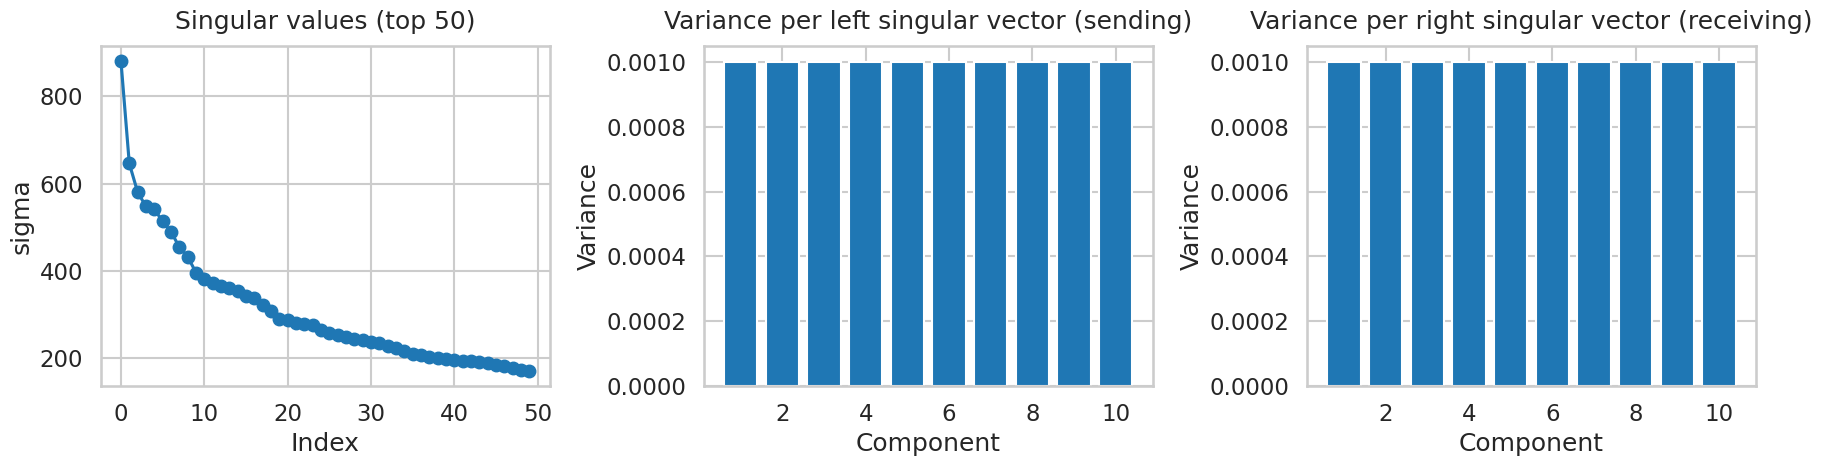

In [41]:
B = modularity_matrix(adj, null_model='outin')
U, S, V = sorted_svd(B)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(S[:50], marker='o')
axes[0].set_title('Singular values (top 50)')
axes[0].set_xlabel('Index')
axes[0].set_ylabel('sigma')

axes[1].bar(range(1, 11), U[:, :10].var(axis=0))
axes[1].set_title('Variance per left singular vector (sending)')
axes[1].set_xlabel('Component')
axes[1].set_ylabel('Variance')

axes[2].bar(range(1, 11), V[:, :10].var(axis=0))
axes[2].set_title('Variance per right singular vector (receiving)')
axes[2].set_xlabel('Component')
axes[2].set_ylabel('Variance')
plt.tight_layout()
plt.show()


In [42]:
print(S[:10])
print("Ratios S[k]/S[k+1] (top 9):")
print(S[:9] / S[1:10])

# node_list: Index of root_ids in the same order as rows of adj/B/U/V
root_ids = np.array(node_list, dtype=int)

labels = np.array(["Other"] * len(root_ids), dtype=object)
labels[np.isin(root_ids, list(pns))] = "PN"
labels[np.isin(root_ids, list(kcs))] = "KC"
labels[np.isin(root_ids, list(mbons))] = "MBON"

print(pd.Series(labels).value_counts())

[880.6262926  646.12061111 580.53769863 547.66540659 541.8006657
 513.30400741 489.67842503 454.88094371 432.77742684 396.20955791]
Ratios S[k]/S[k+1] (top 9):
[1.36294413 1.11296926 1.06002258 1.01082454 1.05551614 1.04824714
 1.076498   1.05107364 1.09229426]
KC      576
PN      364
MBON     60
Name: count, dtype: int64


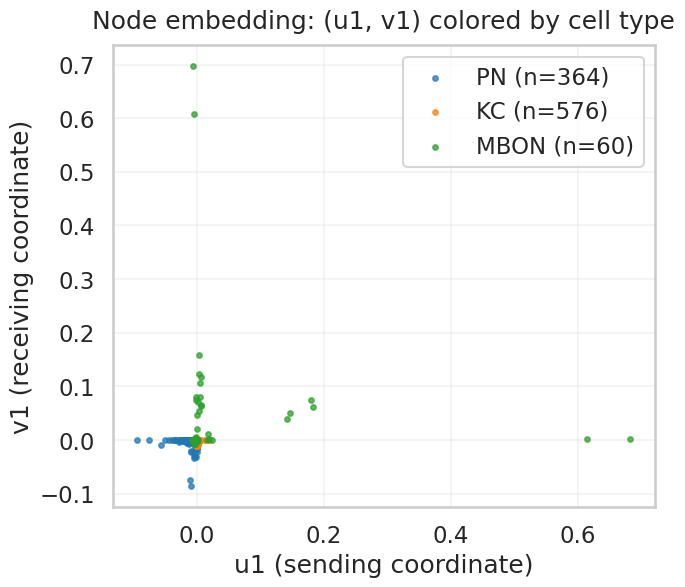

In [43]:
u1 = U[:, 0]  # first left singular vector (sending)
v1 = V[:, 0]  # first right singular vector (receiving)

plt.figure(figsize=(7, 6))

for t in ["PN", "KC", "MBON", "Other"]:
    mask = (labels == t)
    if mask.sum() == 0:
        continue
    plt.scatter(u1[mask], v1[mask], s=12, alpha=0.7, label=f"{t} (n={mask.sum()})")

plt.xlabel("u1 (sending coordinate)")
plt.ylabel("v1 (receiving coordinate)")
plt.title("Node embedding: (u1, v1) colored by cell type")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()


In [44]:
from sklearn.preprocessing import StandardScaler

N = 8
K = 12

pre  = connections_roi["pre_idx"].to_numpy(int)
post = connections_roi["post_idx"].to_numpy(int)

# Build X WITHOUT sigma scaling
X_parts = []
for k in range(N):
    X_parts.append(U[pre, k])   # sender coord
    X_parts.append(V[post, k])  # receiver coord
X = np.vstack(X_parts).T

# Standardize columns so k-means doesn't get dominated by a few dims
X = StandardScaler().fit_transform(X)

w = connections_roi[EDGE_WEIGHT_COL].to_numpy(float)

km = KMeans(n_clusters=K, n_init=50, random_state=0)
connections_roi["edge_cluster"] = km.fit_predict(X, sample_weight=w)

## Directed modularity baselines (NetworkX) + comparison


In [45]:
# Step A: build directed graph from ROI edges (reuse connections_roi)
n = adj.shape[0]
G = nx.DiGraph()
G.add_nodes_from(range(n))

for row in connections_roi.itertuples(index=False):
    u = int(row.pre_idx)
    v = int(row.post_idx)
    w = float(getattr(row, EDGE_WEIGHT_COL))
    if G.has_edge(u, v):
        G[u][v][EDGE_WEIGHT_COL] += w
    else:
        G.add_edge(u, v, **{EDGE_WEIGHT_COL: w})

total_weight_graph = sum(d.get(EDGE_WEIGHT_COL, 0.0) for _, _, d in G.edges(data=True))
print(f"G total weight ({EDGE_WEIGHT_COL}): {total_weight_graph}")
print(f"adj sum: {adj.sum()}")

# Step B: NetworkX modularity baselines
comms_louvain = nx.community.louvain_communities(G, weight=EDGE_WEIGHT_COL, seed=0)
Q_louvain = nx.community.modularity(G, comms_louvain, weight=EDGE_WEIGHT_COL)

comms_greedy = list(nx.community.greedy_modularity_communities(G, weight=EDGE_WEIGHT_COL))
Q_greedy = nx.community.modularity(G, comms_greedy, weight=EDGE_WEIGHT_COL)

print(f"Louvain communities: {len(comms_louvain)}, modularity: {Q_louvain:.4f}")
print(f"Greedy communities: {len(comms_greedy)}, modularity: {Q_greedy:.4f}")


G total weight (syn_count): 147580.0
adj sum: 147580.0
Louvain communities: 8, modularity: 0.5621
Greedy communities: 9, modularity: 0.5574


In [46]:
from collections import Counter

# Step C: node-level majority vote for bimodularity edge clusters
pre_idx = connections_roi["pre_idx"].to_numpy(int)
post_idx = connections_roi["post_idx"].to_numpy(int)
edge_clusters = connections_roi["edge_cluster"].to_numpy(int)
edge_weights = connections_roi[EDGE_WEIGHT_COL].to_numpy(float)

counts = [Counter() for _ in range(n)]
for u, v, c in zip(pre_idx, post_idx, edge_clusters):
    counts[u][c] += 1
    counts[v][c] += 1

node_comm_bimod = np.full(n, -1, dtype=int)
for i, ctr in enumerate(counts):
    if ctr:
        # Majority vote; break ties by smallest cluster id
        node_comm_bimod[i] = max(ctr.items(), key=lambda kv: (kv[1], -kv[0]))[0]

n_unassigned = int((node_comm_bimod == -1).sum())
print(f"Bimodularity majority vote assigned {n - n_unassigned} nodes; unassigned: {n_unassigned}")

def communities_to_node_comm(communities, n_nodes):
    comms_sorted = sorted([set(c) for c in communities], key=lambda s: (-len(s), min(s)))
    node_comm = np.full(n_nodes, -1, dtype=int)
    for cid, nodes in enumerate(comms_sorted):
        for node in nodes:
            node_comm[node] = cid
    return node_comm, comms_sorted

node_comm_louvain, comms_louvain_sorted = communities_to_node_comm(comms_louvain, n)
node_comm_greedy, comms_greedy_sorted = communities_to_node_comm(comms_greedy, n)


Bimodularity majority vote assigned 999 nodes; unassigned: 1


In [47]:
# Step D: summary tables
def node_comm_to_communities(node_comm):
    communities = []
    for cid in np.unique(node_comm):
        nodes = set(np.where(node_comm == cid)[0])
        communities.append(nodes)
    return communities

nx_modularity_bimod_majority = nx.community.modularity(
    G, node_comm_to_communities(node_comm_bimod), weight=EDGE_WEIGHT_COL
)
print(f"nx_modularity_bimod_majority: {nx_modularity_bimod_majority:.4f}")

def summarize_partition(node_comm, method, modularity_score, labels, drop_label=-1):
    rows = []
    unique = [c for c in np.unique(node_comm) if c != drop_label]
    sizes = {c: int((node_comm == c).sum()) for c in unique}
    comm_order = sorted(unique, key=lambda c: (-sizes[c], c))
    for cid in comm_order:
        idx = np.where(node_comm == cid)[0]
        types = labels[idx]
        counts = pd.Series(types).value_counts()
        dom_type = counts.idxmax()
        dom_pct = float(counts.max() / len(idx) * 100)
        rows.append({
            "method": method,
            "community_id": int(cid),
            "size": len(idx),
            "dominant_node_type": dom_type,
            "dominant_pct": round(dom_pct, 2),
            "node_type_mix": counts.to_dict(),
            "modularity_score": modularity_score,
        })
    return pd.DataFrame(rows), comm_order

summary_bimod, order_bimod = summarize_partition(
    node_comm_bimod, "bimod-majority", nx_modularity_bimod_majority, labels, drop_label=-1
)
summary_louvain, order_louvain = summarize_partition(
    node_comm_louvain, "louvain", Q_louvain, labels
)
summary_greedy, order_greedy = summarize_partition(
    node_comm_greedy, "greedy", Q_greedy, labels
)

print("Bimodularity majority summary:")
display(summary_bimod)

print("Louvain summary:")
display(summary_louvain)

print("Greedy summary:")
display(summary_greedy)


nx_modularity_bimod_majority: 0.0690
Bimodularity majority summary:


,method,community_id,size,dominant_node_type,dominant_pct,node_type_mix,modularity_score
0,bimod-majority,3,939,KC,58.79,"{'KC': 552, 'PN': 341, 'MBON': 46}",0.069049
1,bimod-majority,0,22,KC,63.64,"{'KC': 14, 'PN': 8}",0.069049
2,bimod-majority,5,13,KC,69.23,"{'KC': 9, 'PN': 4}",0.069049
3,bimod-majority,6,6,MBON,100.00,{'MBON': 6},0.069049
4,bimod-majority,10,5,MBON,100.00,{'MBON': 5},0.069049
5,bimod-majority,4,4,PN,75.00,"{'PN': 3, 'KC': 1}",0.069049
6,bimod-majority,8,3,PN,100.00,{'PN': 3},0.069049
7,bimod-majority,9,3,PN,100.00,{'PN': 3},0.069049
8,bimod-majority,7,2,PN,100.00,{'PN': 2},0.069049
9,bimod-majority,1,1,MBON,100.00,{'MBON': 1},0.069049


Louvain summary:


,method,community_id,size,dominant_node_type,dominant_pct,node_type_mix,modularity_score
0,louvain,0,500,KC,77.00,"{'KC': 385, 'PN': 113, 'MBON': 2}",0.562105
1,louvain,1,262,KC,53.44,"{'KC': 140, 'PN': 120, 'MBON': 2}",0.562105
2,louvain,2,137,PN,79.56,"{'PN': 109, 'KC': 28}",0.562105
3,louvain,3,48,MBON,83.33,"{'MBON': 40, 'KC': 8}",0.562105
4,louvain,4,22,PN,63.64,"{'PN': 14, 'KC': 8}",0.562105
5,louvain,5,21,MBON,71.43,"{'MBON': 15, 'KC': 6}",0.562105
6,louvain,6,9,PN,88.89,"{'PN': 8, 'KC': 1}",0.562105
7,louvain,7,1,MBON,100.00,{'MBON': 1},0.562105


Greedy summary:


,method,community_id,size,dominant_node_type,dominant_pct,node_type_mix,modularity_score
0,greedy,0,322,KC,77.64,"{'KC': 250, 'PN': 71, 'MBON': 1}",0.557418
1,greedy,1,250,KC,56.40,"{'KC': 141, 'PN': 107, 'MBON': 2}",0.557418
2,greedy,2,162,KC,75.93,"{'KC': 123, 'PN': 39}",0.557418
3,greedy,3,104,PN,89.42,"{'PN': 93, 'KC': 11}",0.557418
4,greedy,4,78,PN,52.56,"{'PN': 41, 'KC': 37}",0.557418
5,greedy,5,56,MBON,85.71,"{'MBON': 48, 'KC': 8}",0.557418
6,greedy,6,19,PN,68.42,"{'PN': 13, 'KC': 6}",0.557418
7,greedy,7,8,MBON,100.00,{'MBON': 8},0.557418
8,greedy,8,1,MBON,100.00,{'MBON': 1},0.557418


bimod-majority: excluded 1 unassigned nodes from plots.


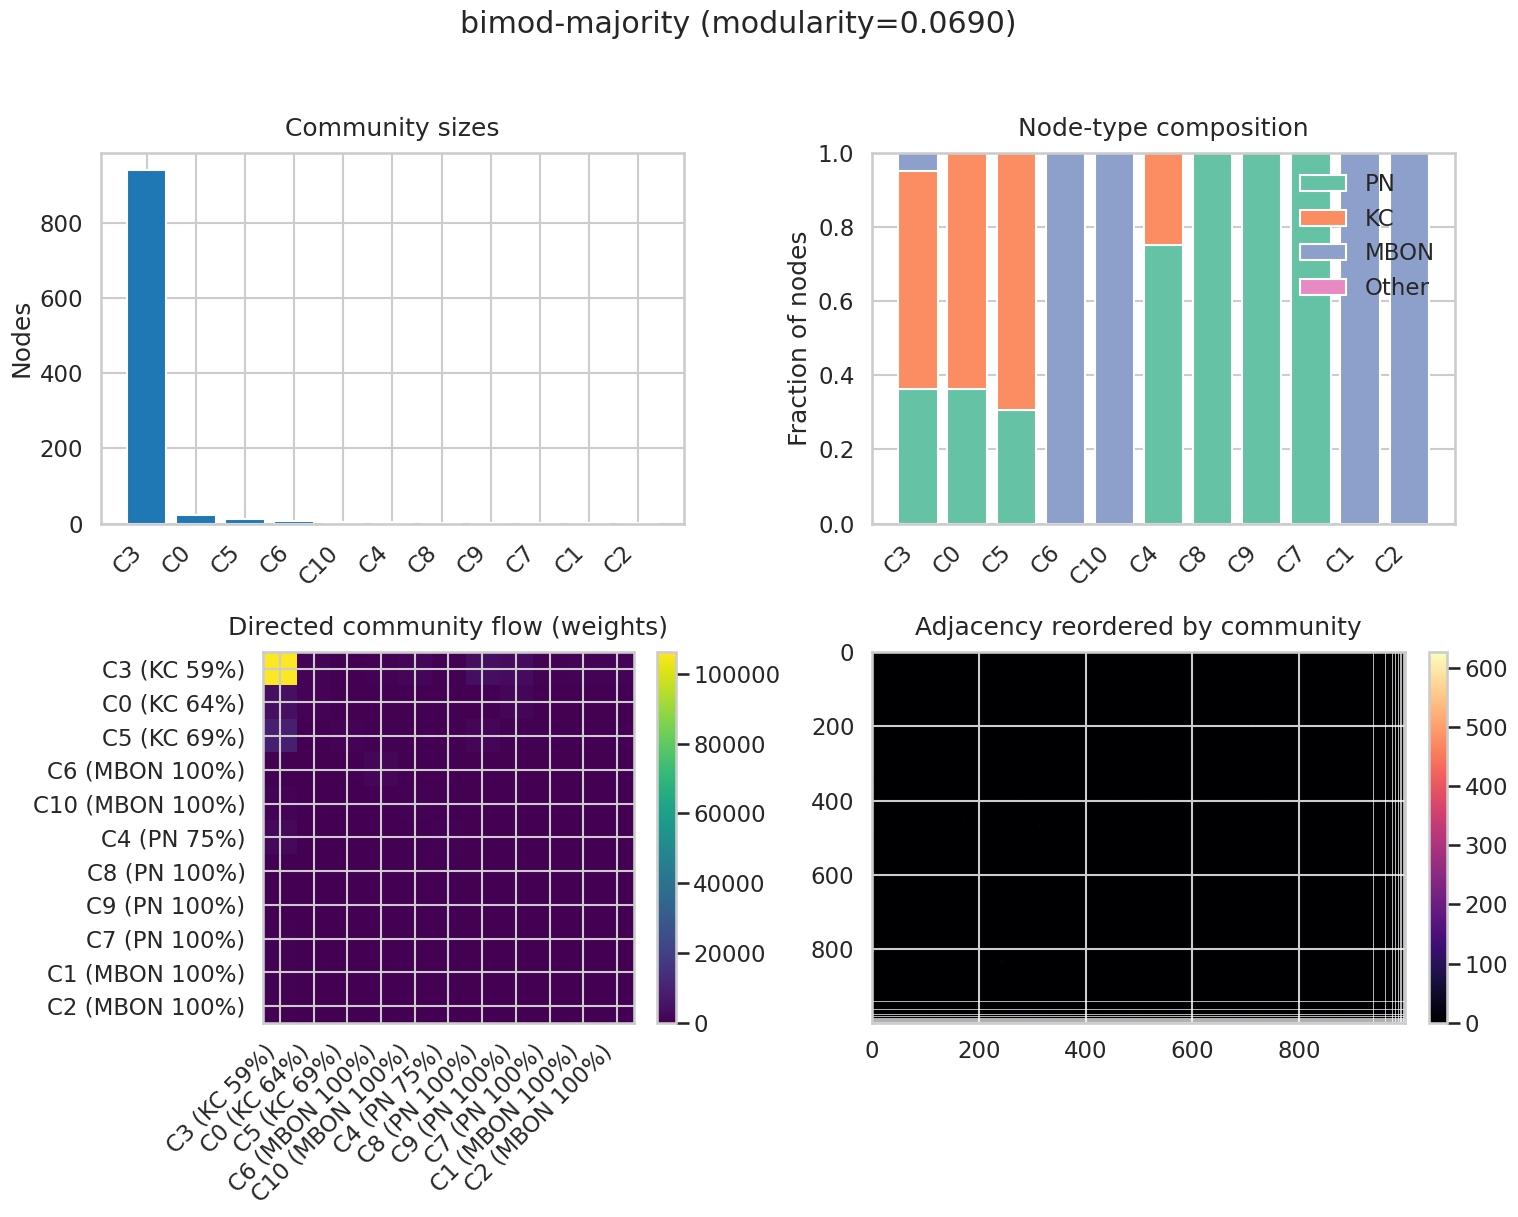

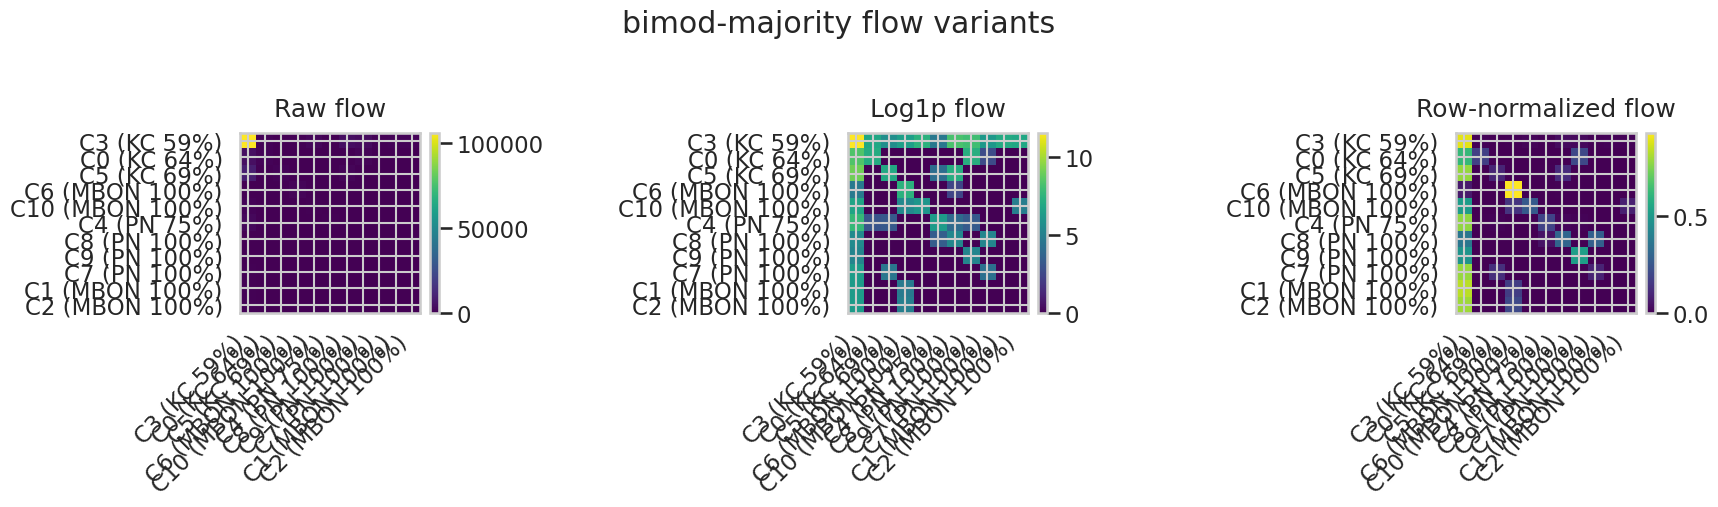

bimod-majority type->type flow (PN/KC/MBON)


,PN,KC,MBON
PN,48347.0,72770.0,665.0
KC,0.0,166.0,6502.0
MBON,451.0,0.0,18679.0


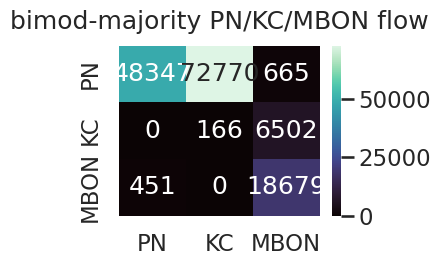

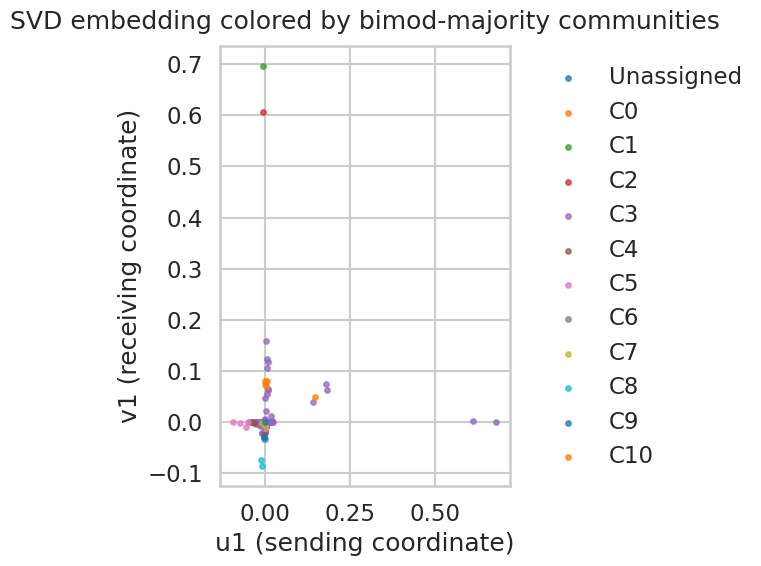

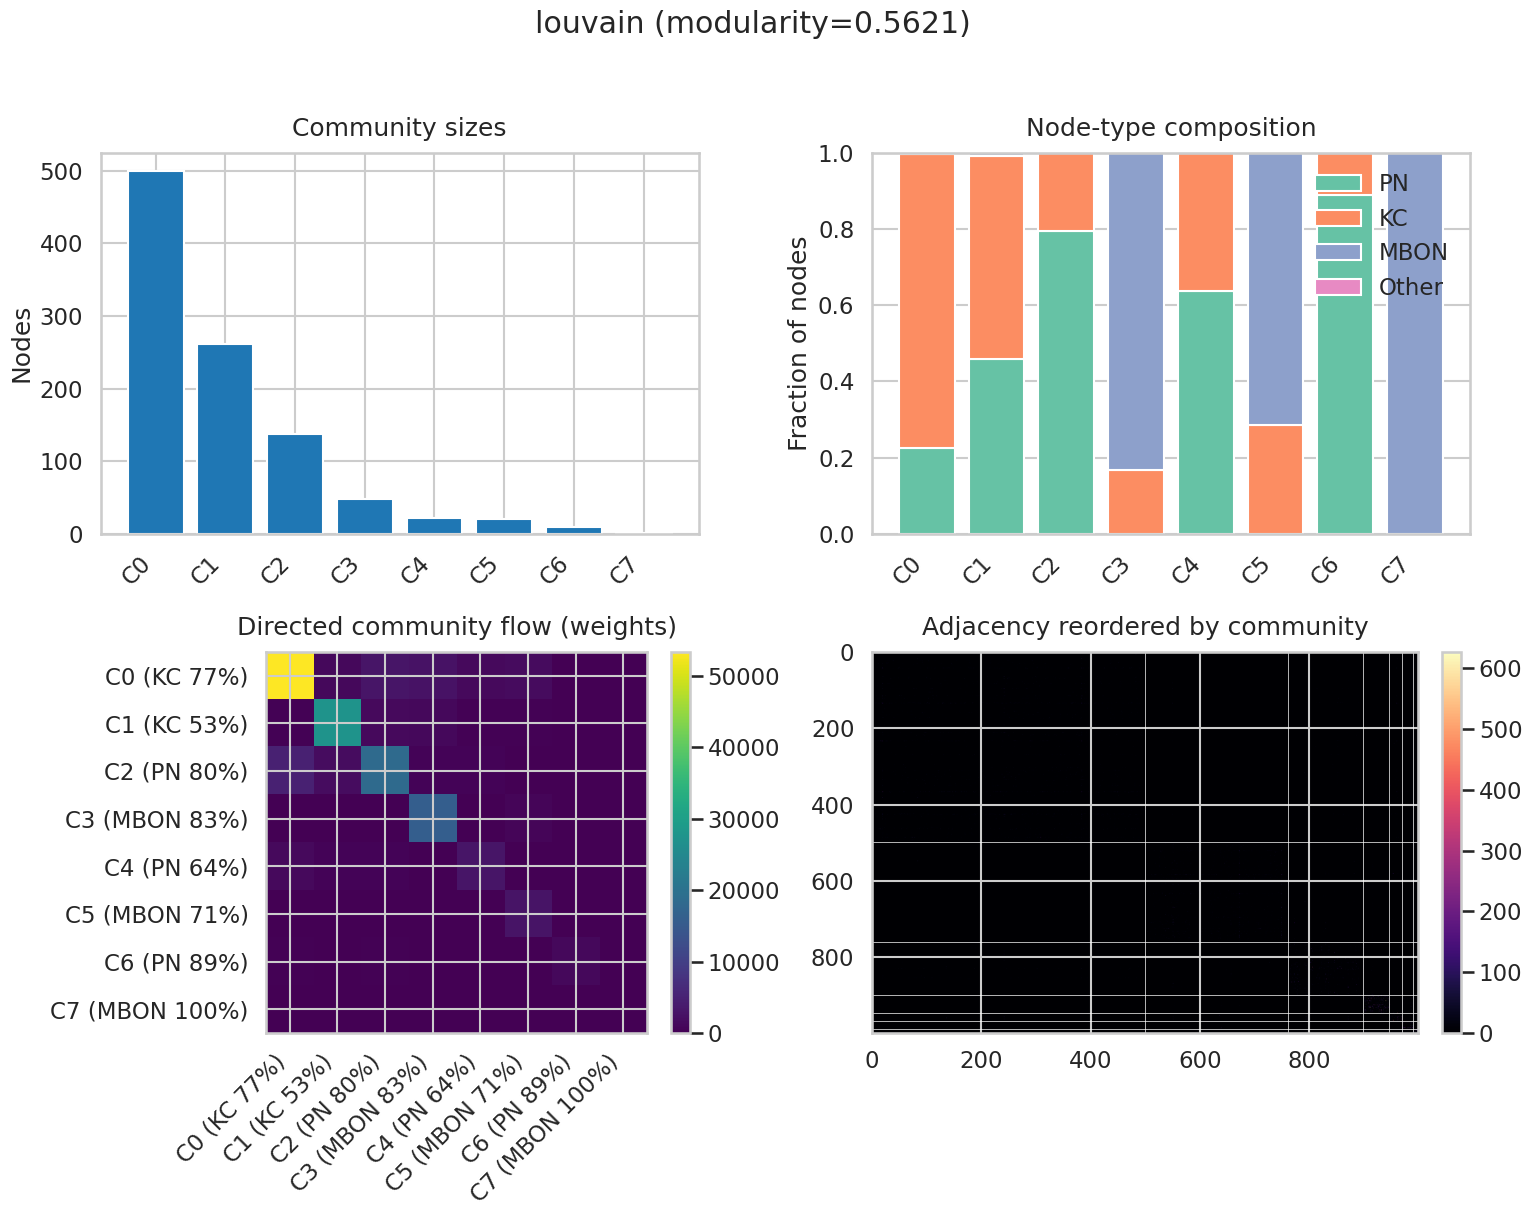

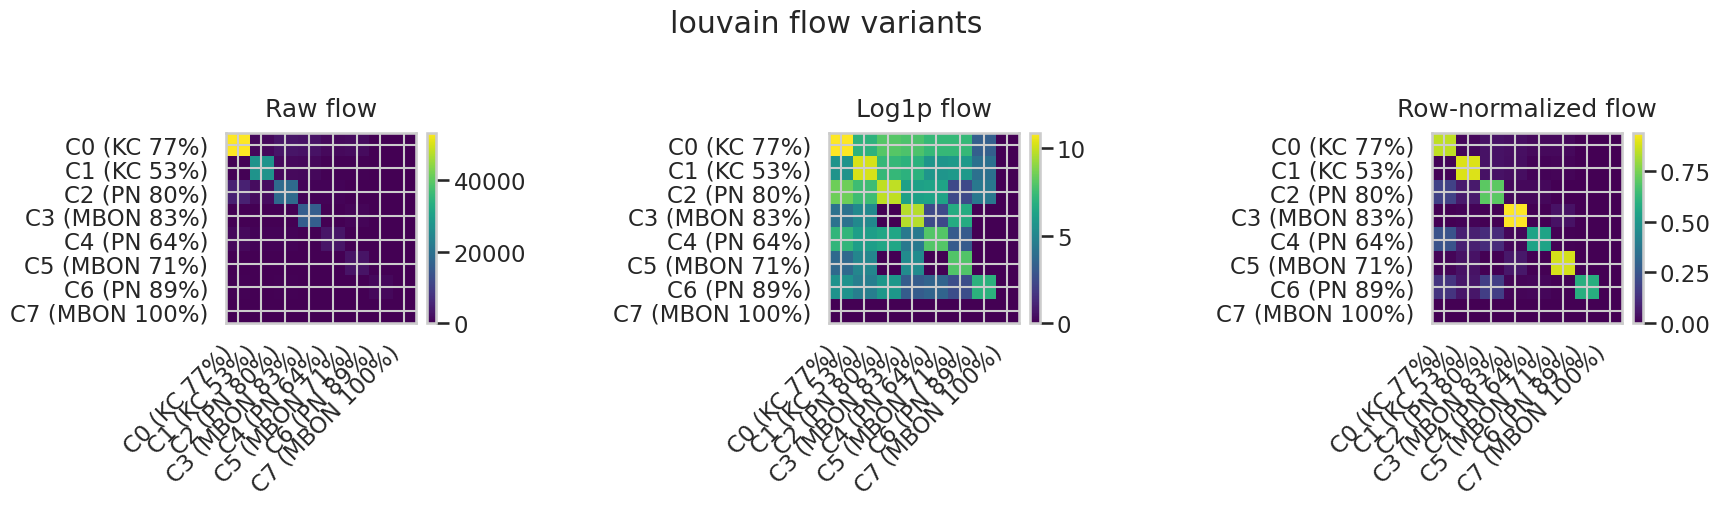

louvain type->type flow (PN/KC/MBON)


,PN,KC,MBON
PN,48347.0,72770.0,665.0
KC,0.0,166.0,6502.0
MBON,451.0,0.0,18679.0


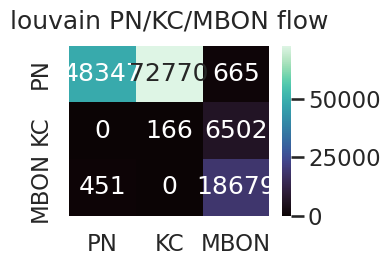

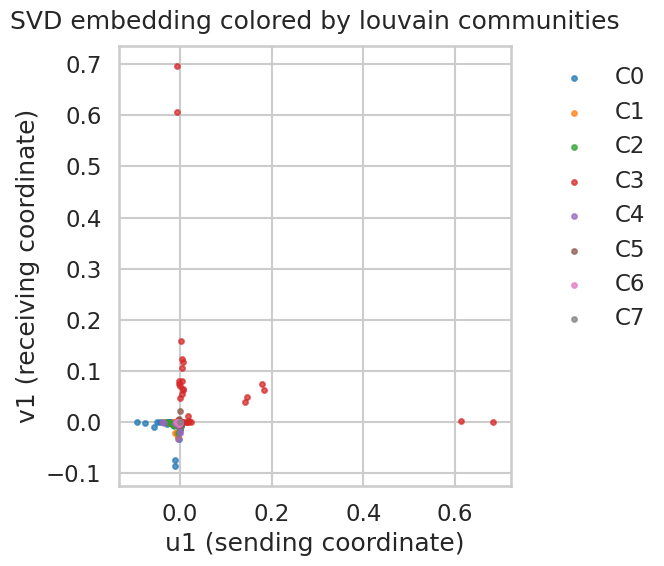

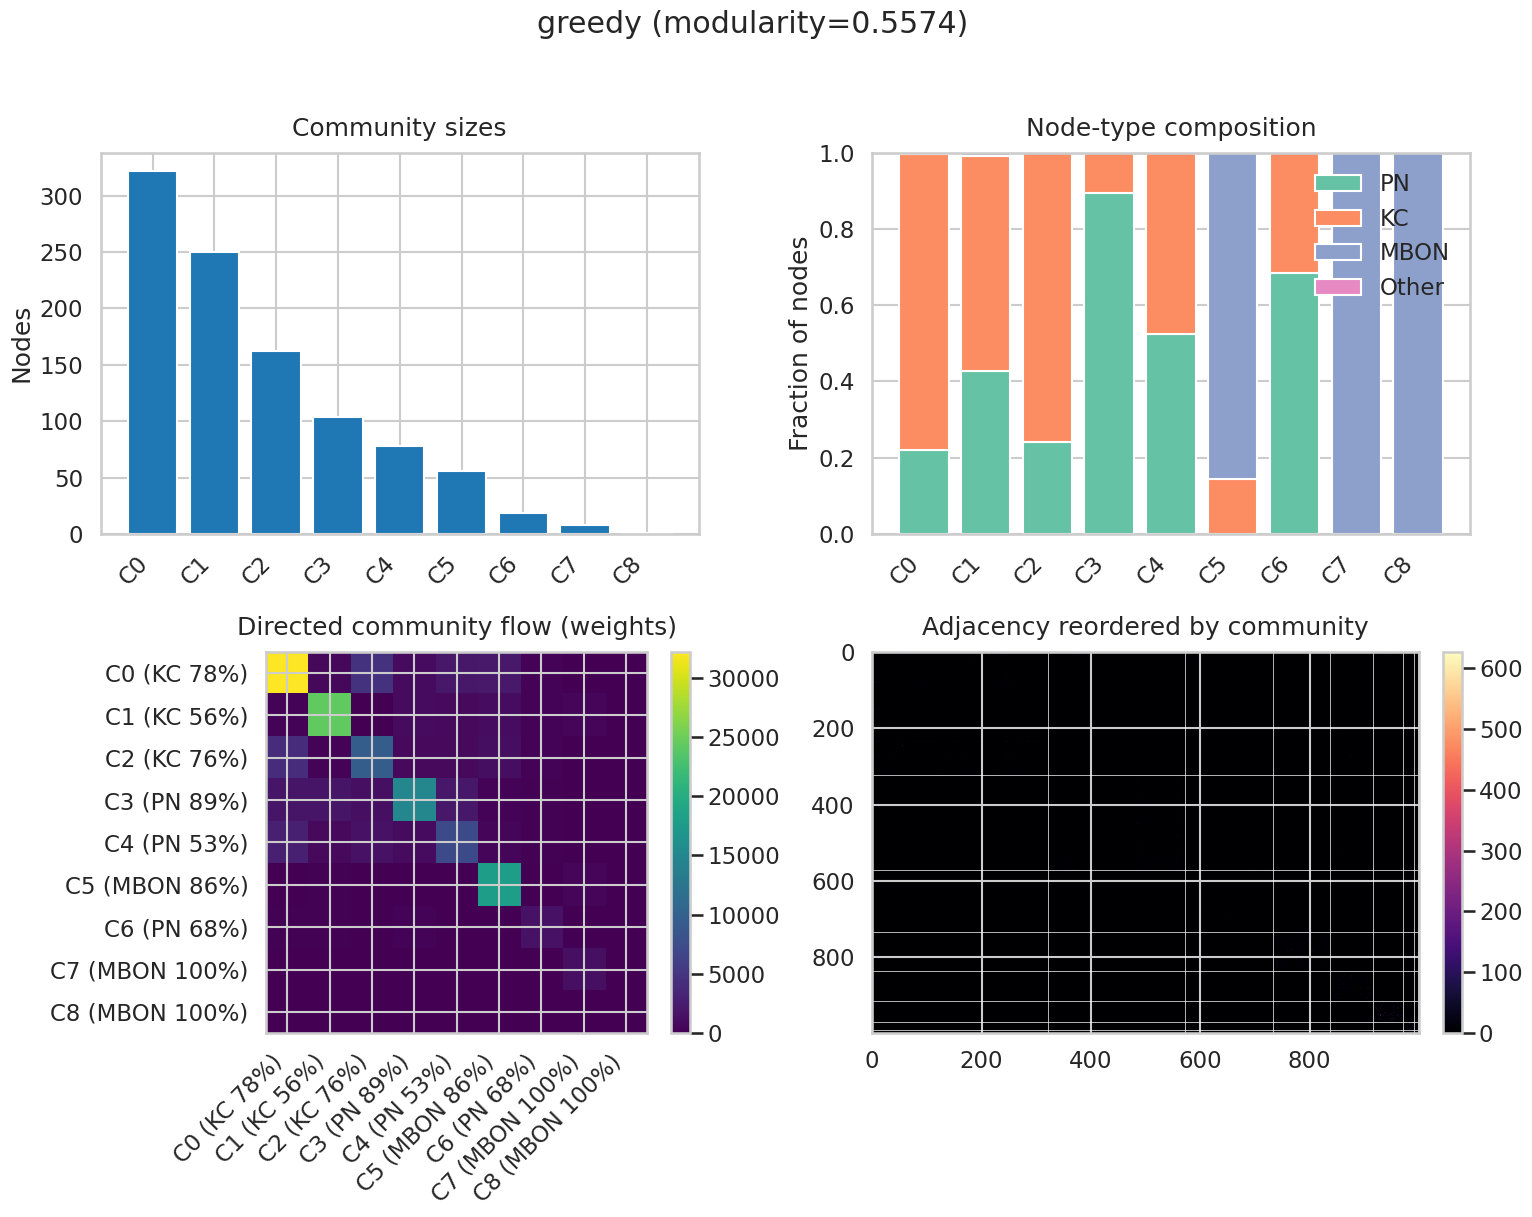

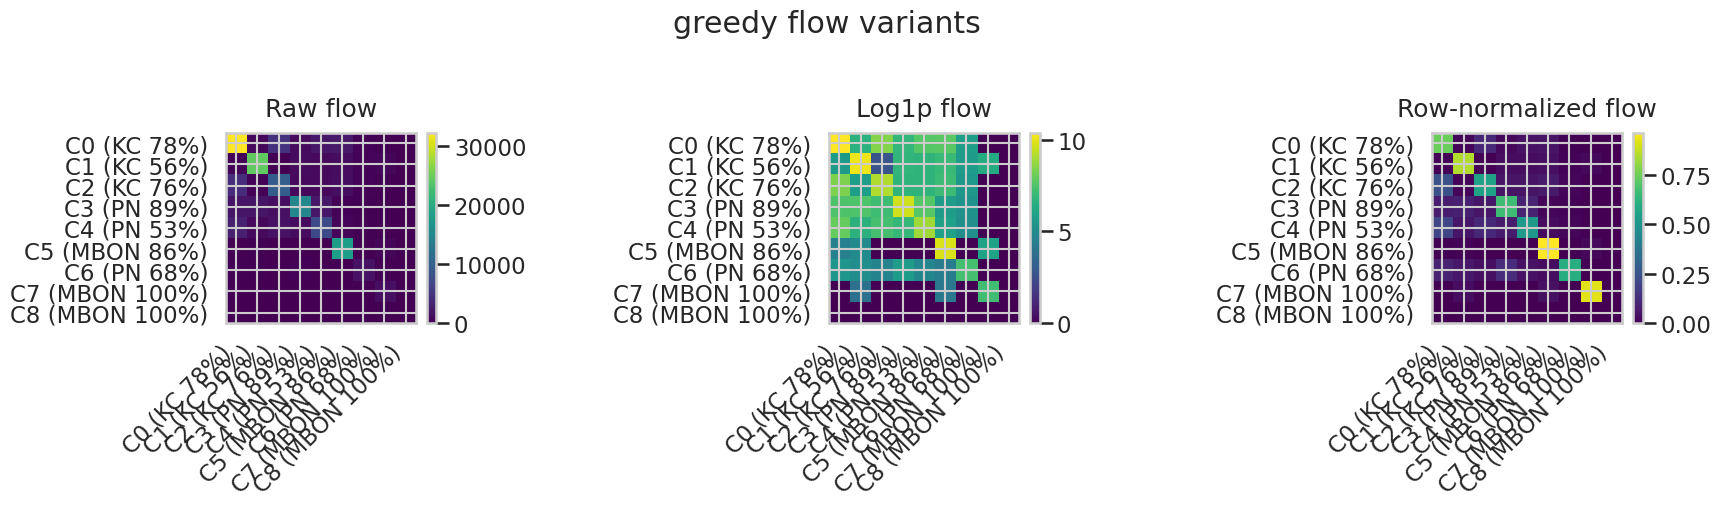

greedy type->type flow (PN/KC/MBON)


,PN,KC,MBON
PN,48347.0,72770.0,665.0
KC,0.0,166.0,6502.0
MBON,451.0,0.0,18679.0


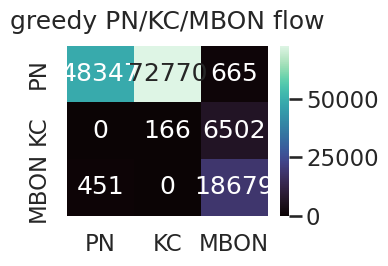

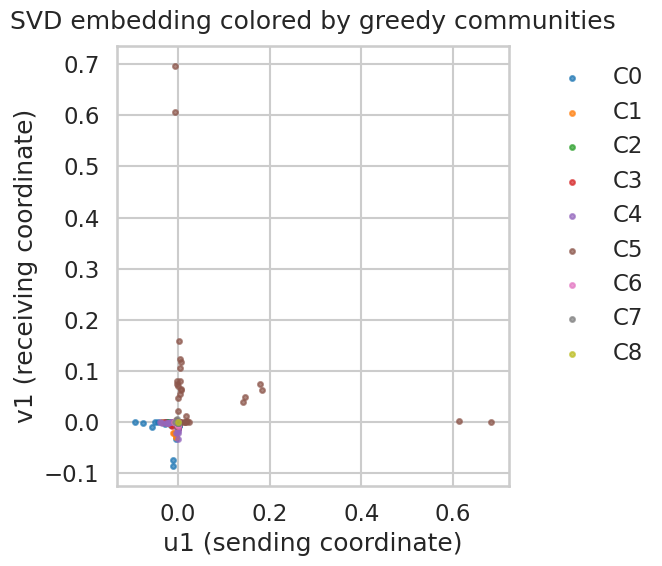

/tmp/ipykernel_8651/3510973404.py:219: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


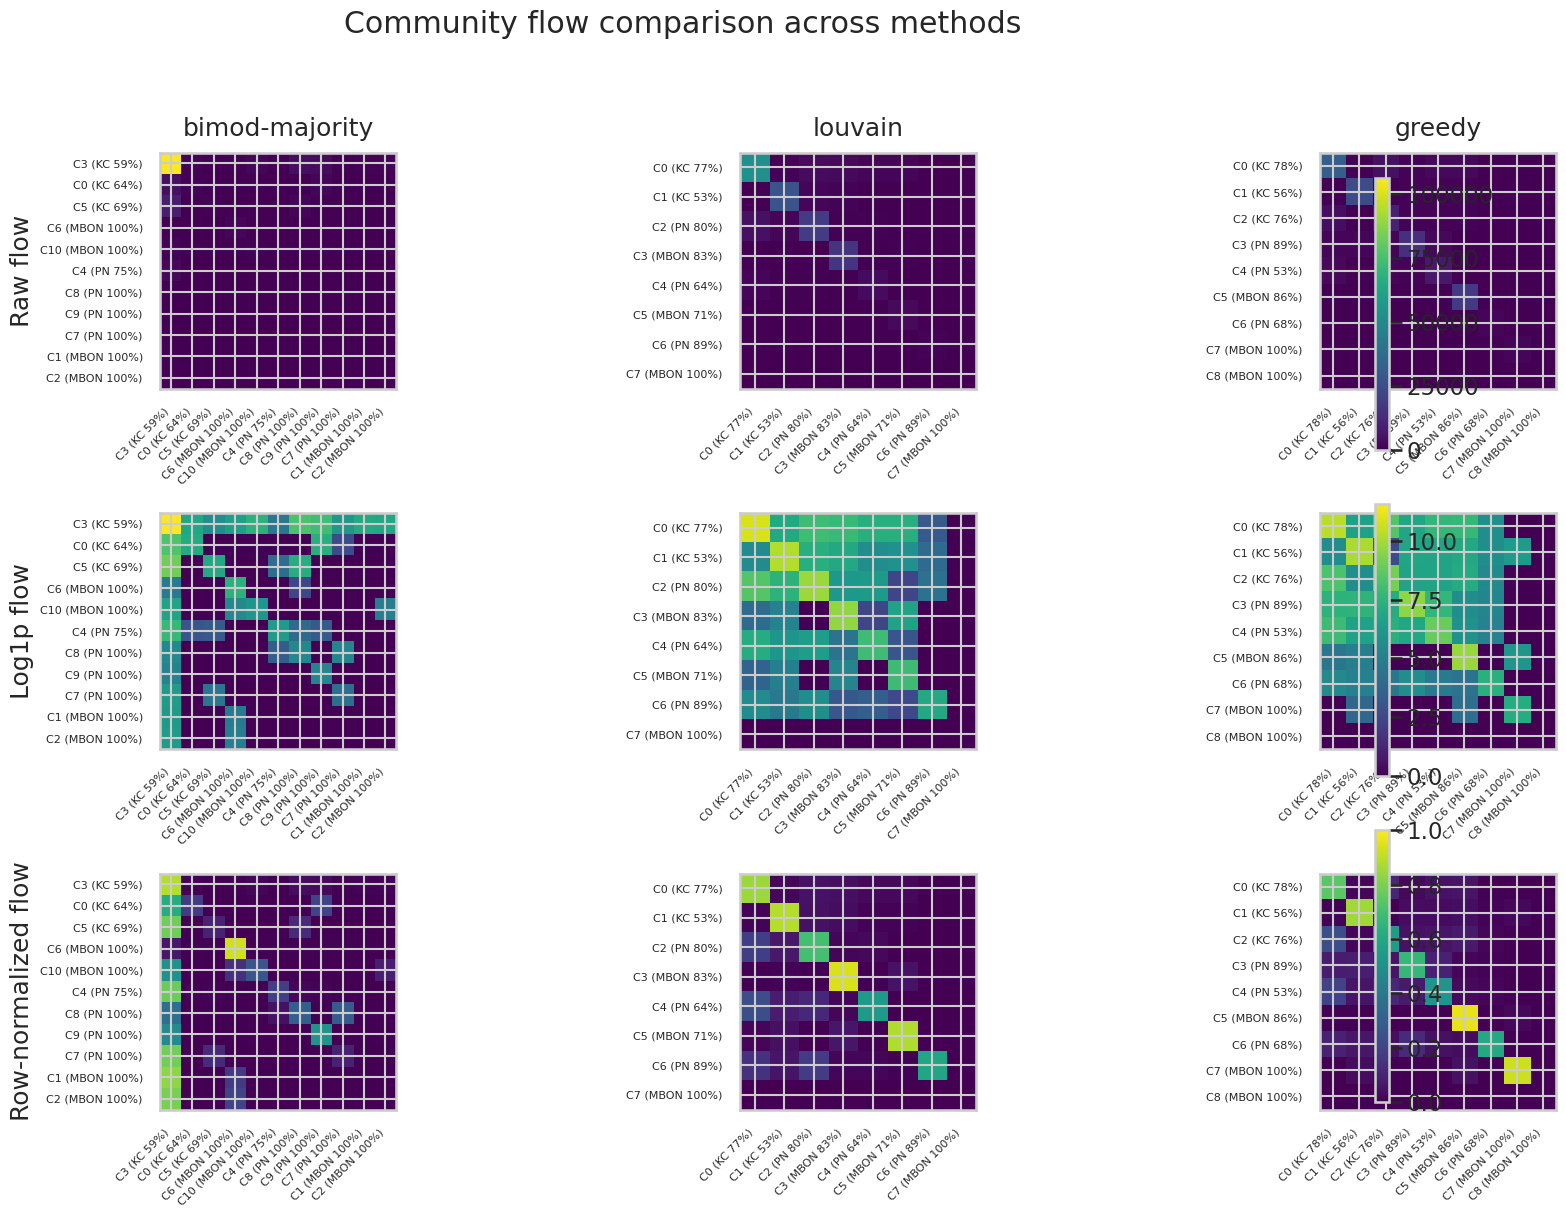

In [48]:
from matplotlib.gridspec import GridSpec

# Step E: visualizations for all three methods
RUN_SVD_BASELINES = True

def compute_flow_matrix(pre_idx, post_idx, weights, node_comm, comm_order):
    comm_to_idx = {cid: i for i, cid in enumerate(comm_order)}
    F = np.zeros((len(comm_order), len(comm_order)), dtype=float)
    for u, v, w in zip(pre_idx, post_idx, weights):
        cu = comm_to_idx.get(node_comm[u])
        cv = comm_to_idx.get(node_comm[v])
        if cu is None or cv is None:
            continue
        F[cu, cv] += w
    return F

def row_normalize(M):
    row_sums = M.sum(axis=1, keepdims=True)
    return np.divide(M, row_sums, out=np.zeros_like(M), where=row_sums != 0)

def community_tick_labels(summary_df, comm_order):
    dom_map = summary_df.set_index("community_id")[["dominant_node_type", "dominant_pct"]].to_dict("index")
    return [
        f"C{cid} ({dom_map[cid]['dominant_node_type']} {dom_map[cid]['dominant_pct']:.0f}%)"
        for cid in comm_order
    ]

def compute_type_flow(pre_idx, post_idx, weights, labels, node_comm=None):
    types = ["PN", "KC", "MBON"]
    type_to_idx = {t: i for i, t in enumerate(types)}
    mask_nodes = None
    if node_comm is not None:
        mask_nodes = node_comm >= 0
    M = np.zeros((len(types), len(types)), dtype=float)
    for u, v, w in zip(pre_idx, post_idx, weights):
        if mask_nodes is not None and (not mask_nodes[u] or not mask_nodes[v]):
            continue
        tu = labels[u]
        tv = labels[v]
        if tu in type_to_idx and tv in type_to_idx:
            M[type_to_idx[tu], type_to_idx[tv]] += w
    return M, types

def plot_flow_variants(F, tick_labels, title_prefix):
    flow_log = np.log1p(F)
    flow_row = row_normalize(F)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    mats = [F, flow_log, flow_row]
    titles = ["Raw flow", "Log1p flow", "Row-normalized flow"]
    for ax, mat, t in zip(axes, mats, titles):
        im = ax.imshow(mat, cmap="viridis")
        ax.set_xticks(range(len(tick_labels)))
        ax.set_yticks(range(len(tick_labels)))
        ax.set_xticklabels(tick_labels, rotation=45, ha="right")
        ax.set_yticklabels(tick_labels)
        ax.set_title(t)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(f"{title_prefix} flow variants", y=1.02)
    plt.tight_layout()
    plt.show()

    return flow_log, flow_row

def plot_partition_panels(method, node_comm, summary_df, comm_order, modularity_score):
    type_order = ["PN", "KC", "MBON", "Other"]
    sizes = summary_df.set_index("community_id").loc[comm_order, "size"].to_numpy(int)

    comp = []
    for cid in comm_order:
        idx = np.where(node_comm == cid)[0]
        counts = pd.Series(labels[idx]).value_counts()
        comp.append([counts.get(t, 0) for t in type_order])
    comp_df = pd.DataFrame(comp, index=comm_order, columns=type_order)
    comp_pct = comp_df.div(comp_df.sum(axis=1), axis=0).fillna(0.0)

    F = compute_flow_matrix(pre_idx, post_idx, edge_weights, node_comm, comm_order)

    node_order = np.concatenate([np.where(node_comm == cid)[0] for cid in comm_order])
    adj_reordered = adj[np.ix_(node_order, node_order)]
    boundaries = np.cumsum([np.sum(node_comm == cid) for cid in comm_order])

    tick_labels = community_tick_labels(summary_df, comm_order)

    fig = plt.figure(figsize=(16, 12))
    gs = GridSpec(2, 2, figure=fig)

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.bar(range(len(comm_order)), sizes, color="tab:blue")
    ax1.set_xticks(range(len(comm_order)))
    ax1.set_xticklabels([f"C{c}" for c in comm_order], rotation=45, ha="right")
    ax1.set_ylabel("Nodes")
    ax1.set_title("Community sizes")

    ax2 = fig.add_subplot(gs[0, 1])
    bottom = np.zeros(len(comm_order))
    colors = sns.color_palette("Set2", n_colors=len(type_order))
    for t, col in zip(type_order, colors):
        vals = comp_pct[t].to_numpy()
        ax2.bar(range(len(comm_order)), vals, bottom=bottom, label=t, color=col)
        bottom += vals
    ax2.set_xticks(range(len(comm_order)))
    ax2.set_xticklabels([f"C{c}" for c in comm_order], rotation=45, ha="right")
    ax2.set_ylim(0, 1)
    ax2.set_ylabel("Fraction of nodes")
    ax2.set_title("Node-type composition")
    ax2.legend(loc="upper right", frameon=False)

    ax3 = fig.add_subplot(gs[1, 0])
    im3 = ax3.imshow(F, cmap="viridis")
    ax3.set_xticks(range(len(comm_order)))
    ax3.set_yticks(range(len(comm_order)))
    ax3.set_xticklabels(tick_labels, rotation=45, ha="right")
    ax3.set_yticklabels(tick_labels)
    ax3.set_title("Directed community flow (weights)")
    fig.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

    ax4 = fig.add_subplot(gs[1, 1])
    im4 = ax4.imshow(adj_reordered, cmap="magma", aspect="auto")
    for b in boundaries[:-1]:
        ax4.axhline(b - 0.5, color="white", linewidth=0.5)
        ax4.axvline(b - 0.5, color="white", linewidth=0.5)
    ax4.set_title("Adjacency reordered by community")
    fig.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)

    fig.suptitle(f"{method} (modularity={modularity_score:.4f})", y=1.02)
    plt.tight_layout()
    plt.show()

    flow_log, flow_row = plot_flow_variants(F, tick_labels, method)

    type_flow, type_labels = compute_type_flow(
        pre_idx, post_idx, edge_weights, labels, node_comm=node_comm
    )
    type_flow_df = pd.DataFrame(type_flow, index=type_labels, columns=type_labels)
    print(f"{method} type->type flow (PN/KC/MBON)")
    display(type_flow_df)

    plt.figure(figsize=(4, 3))
    sns.heatmap(type_flow_df, annot=True, fmt=".0f", cmap="mako")
    plt.title(f"{method} PN/KC/MBON flow")
    plt.tight_layout()
    plt.show()

    return {
        "raw": F,
        "log": flow_log,
        "row": flow_row,
        "tick_labels": tick_labels,
    }

def plot_svd_scatter(method, node_comm):
    plt.figure(figsize=(7, 6))
    comms = np.unique(node_comm)
    cmap = plt.get_cmap("tab20")
    for cid in comms:
        mask = node_comm == cid
        if cid == -1:
            color = "lightgray"
            label = "Unassigned"
        else:
            color = cmap(int(cid) % cmap.N)
            label = f"C{cid}"
        plt.scatter(u1[mask], v1[mask], s=12, alpha=0.7, label=label)
    plt.xlabel("u1 (sending coordinate)")
    plt.ylabel("v1 (receiving coordinate)")
    plt.title(f"SVD embedding colored by {method} communities")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)
    plt.tight_layout()
    plt.show()

method_specs = [
    ("bimod-majority", node_comm_bimod, summary_bimod, order_bimod, nx_modularity_bimod_majority),
    ("louvain", node_comm_louvain, summary_louvain, order_louvain, Q_louvain),
    ("greedy", node_comm_greedy, summary_greedy, order_greedy, Q_greedy),
]

flow_results = {}
for method, node_comm, summary_df, comm_order, mod_score in method_specs:
    unassigned = int((node_comm == -1).sum())
    if unassigned:
        print(f"{method}: excluded {unassigned} unassigned nodes from plots.")
    flow_results[method] = plot_partition_panels(method, node_comm, summary_df, comm_order, mod_score)
    if RUN_SVD_BASELINES:
        plot_svd_scatter(method, node_comm)

# Combined flow comparison grid across methods
method_order = ["bimod-majority", "louvain", "greedy"]
raw_max = max(flow_results[m]["raw"].max() for m in method_order)
log_max = max(flow_results[m]["log"].max() for m in method_order)
row_max = 1.0

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
row_titles = ["Raw flow", "Log1p flow", "Row-normalized flow"]
row_ims = [None, None, None]

for col, method in enumerate(method_order):
    tick_labels = flow_results[method]["tick_labels"]
    mats = [flow_results[method]["raw"], flow_results[method]["log"], flow_results[method]["row"]]
    vmaxs = [raw_max, log_max, row_max]
    for row, mat in enumerate(mats):
        ax = axes[row, col]
        im = ax.imshow(mat, cmap="viridis", vmin=0, vmax=vmaxs[row])
        if row_ims[row] is None:
            row_ims[row] = im
        ax.set_xticks(range(len(tick_labels)))
        ax.set_yticks(range(len(tick_labels)))
        ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)
        ax.set_yticklabels(tick_labels, fontsize=8)
        if row == 0:
            ax.set_title(method)
        if col == 0:
            ax.set_ylabel(row_titles[row])

for row, im in enumerate(row_ims):
    fig.colorbar(im, ax=axes[row, :], fraction=0.02, pad=0.02)

fig.suptitle("Community flow comparison across methods", y=1.02)
plt.tight_layout()
plt.show()


In [49]:
from sklearn.metrics import adjusted_mutual_info_score, normalized_mutual_info_score

# Step F: partition similarity
def pairwise_similarity(a, b):
    mask = (a >= 0) & (b >= 0)
    if mask.sum() == 0:
        return np.nan, np.nan
    ami = adjusted_mutual_info_score(a[mask], b[mask])
    nmi = normalized_mutual_info_score(a[mask], b[mask])
    return ami, nmi

method_names = ["bimod-majority", "louvain", "greedy"]
methods = {
    "bimod-majority": node_comm_bimod,
    "louvain": node_comm_louvain,
    "greedy": node_comm_greedy,
}

ami_mat = pd.DataFrame(index=method_names, columns=method_names, dtype=float)
nmi_mat = pd.DataFrame(index=method_names, columns=method_names, dtype=float)

for a_name in method_names:
    for b_name in method_names:
        ami, nmi = pairwise_similarity(methods[a_name], methods[b_name])
        ami_mat.loc[a_name, b_name] = ami
        nmi_mat.loc[a_name, b_name] = nmi

print("AMI")
display(ami_mat.round(3))
print("NMI")
display(nmi_mat.round(3))


AMI


,bimod-majority,louvain,greedy
bimod-majority,1.000,0.104,0.073
louvain,0.104,1.000,0.634
greedy,0.073,0.634,1.000


NMI


,bimod-majority,louvain,greedy
bimod-majority,1.000,0.127,0.098
louvain,0.127,1.000,0.640
greedy,0.098,0.640,1.000


In [50]:
def summarize_cluster(df, c):
    sub = df[df["edge_cluster"] == c]
    src = sub["pre_idx"].to_numpy()
    tgt = sub["post_idx"].to_numpy()
    src_types = pd.Series(labels[src]).value_counts(normalize=True)
    tgt_types = pd.Series(labels[tgt]).value_counts(normalize=True)
    return len(sub), src_types, tgt_types

for c in range(K):
    m, src_mix, tgt_mix = summarize_cluster(connections_roi, c)
    print(f"\nCluster {c}: edges={m}")
    print("  source mix:", (src_mix*100).round(1).to_dict())
    print("  target mix:", (tgt_mix*100).round(1).to_dict())



Cluster 0: edges=236
  source mix: {'PN': 100.0}
  target mix: {'KC': 78.4, 'PN': 21.6}

Cluster 1: edges=22
  source mix: {'MBON': 95.5, 'KC': 4.5}
  target mix: {'MBON': 100.0}

Cluster 2: edges=17
  source mix: {'MBON': 94.1, 'KC': 5.9}
  target mix: {'MBON': 100.0}

Cluster 3: edges=4703
  source mix: {'PN': 82.6, 'KC': 11.0, 'MBON': 6.4}
  target mix: {'KC': 55.1, 'PN': 27.6, 'MBON': 17.3}

Cluster 4: edges=93
  source mix: {'PN': 100.0}
  target mix: {'KC': 62.4, 'PN': 37.6}

Cluster 5: edges=364
  source mix: {'PN': 100.0}
  target mix: {'KC': 93.4, 'PN': 6.6}

Cluster 6: edges=69
  source mix: {'MBON': 94.2, 'KC': 5.8}
  target mix: {'MBON': 100.0}

Cluster 7: edges=20
  source mix: {'PN': 100.0}
  target mix: {'PN': 100.0}

Cluster 8: edges=170
  source mix: {'PN': 96.5, 'MBON': 3.5}
  target mix: {'PN': 100.0}

Cluster 9: edges=163
  source mix: {'PN': 95.7, 'MBON': 4.3}
  target mix: {'PN': 100.0}

Cluster 10: edges=81
  source mix: {'MBON': 96.3, 'KC': 3.7}
  target mix: {

In [51]:
def node_type(r):
    if r in pns: return "PN"
    if r in kcs: return "KC"
    if r in mbons: return "MBON"
    return "Other"

connections_roi["pre_type"]  = connections_roi["pre_root_id"].map(node_type)
connections_roi["post_type"] = connections_roi["post_root_id"].map(node_type)

ct = pd.crosstab(connections_roi["pre_type"], connections_roi["post_type"])
print(ct)

print("KC->MBON edges:", ((connections_roi["pre_type"]=="KC") & (connections_roi["post_type"]=="MBON")).sum())


post_type    KC  MBON    PN
pre_type                   
KC           12   512     0
MBON          0   480    28
PN         3161    23  1735
KC->MBON edges: 512


In [52]:
kc_mbon = connections_roi[(connections_roi["pre_type"]=="KC") & (connections_roi["post_type"]=="MBON")]
print(kc_mbon["edge_cluster"].value_counts().head(20))


edge_cluster
3     503
6       4
10      3
1       1
2       1
Name: count, dtype: int64


In [53]:
# Identify the largest cluster dynamically
largest_cluster = connections_roi["edge_cluster"].value_counts().idxmax()
print(f"Largest cluster is: {largest_cluster}")

pipeline = connections_roi[connections_roi["edge_cluster"] == largest_cluster]

src_mix = pipeline["pre_type"].value_counts(normalize=True)
tgt_mix = pipeline["post_type"].value_counts(normalize=True)

print(f"Pipeline (Cluster {largest_cluster}) source mix (%):", (src_mix*100).round(1))
print(f"Pipeline (Cluster {largest_cluster}) target mix (%):", (tgt_mix*100).round(1))

print("Source counts:")
print(pipeline["pre_type"].value_counts())

print("\nTarget counts:")
print(pipeline["post_type"].value_counts())

Largest cluster is: 3
Pipeline (Cluster 3) source mix (%): pre_type
PN      82.6
KC      11.0
MBON     6.4
Name: proportion, dtype: float64
Pipeline (Cluster 3) target mix (%): post_type
KC      55.1
PN      27.6
MBON    17.3
Name: proportion, dtype: float64
Source counts:
pre_type
PN      3886
KC       515
MBON     302
Name: count, dtype: int64

Target counts:
post_type
KC      2590
PN      1300
MBON     813
Name: count, dtype: int64


In [54]:
sub = connections_roi[connections_roi["edge_cluster"]==largest_cluster].copy()

pre  = sub["pre_idx"].to_numpy(int)
post = sub["post_idx"].to_numpy(int)

N2 = 8
X_parts=[]
for k in range(N2):
    X_parts.append(U[pre,k])
    X_parts.append(V[post,k])
X0 = np.vstack(X_parts).T

from sklearn.preprocessing import StandardScaler
X0 = StandardScaler().fit_transform(X0)

from sklearn.cluster import KMeans
K2 = 5
sub["sub_cluster"] = KMeans(n_clusters=K2, n_init=50, random_state=0).fit_predict(X0)

# show KC->MBON enrichment per subcluster
for c in range(K2):
    s = sub[sub["sub_cluster"]==c]
    print(c, len(s),
          (s["pre_type"].value_counts(normalize=True)*100).round(1).to_dict(),
          (s["post_type"].value_counts(normalize=True)*100).round(1).to_dict())

0 118 {'MBON': 90.7, 'PN': 9.3} {'MBON': 90.7, 'PN': 9.3}
1 2765 {'PN': 95.3, 'KC': 2.6, 'MBON': 2.1} {'KC': 61.7, 'PN': 34.0, 'MBON': 4.4}
2 752 {'KC': 58.9, 'PN': 22.9, 'MBON': 18.2} {'MBON': 77.8, 'PN': 22.2}
3 970 {'PN': 100.0} {'KC': 91.2, 'PN': 8.8}
4 98 {'PN': 100.0} {'PN': 100.0}


In [55]:
import pandas as pd

from matplotlib.figure import Figure
from matplotlib.gridspec import GridSpecFromSubplotSpec

from matplotlib.lines import Line2D
import numpy as np
from scipy.linalg import block_diag
import networkx as nx

from typing import Optional

from matplotlib.axes import Axes
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from matplotlib.colors import to_rgb, to_rgba, ListedColormap
from matplotlib.patheffects import withStroke


def plot_graph_embedding(
    matrix: np.ndarray,
    vector_id: int = 0,
    n_com: int = 4,
    ax: Optional[Axes] = None,
    use_cmap: bool = True,
    cmap: str = "plasma",
    static_color: str = "tab:blue",
    write_label: bool = False,
    write_var: bool = False,
    label_lw: int = 3,
    directed_edges: bool = True,
    edge_alpha: float = 0.02,
    fontscale: float = 1.2,
    title_letter: str = "",
    override_title: Optional[str] = None,
    node_clusers: Optional[np.ndarray] = None,
    **kwargs,
) -> Axes:

    # Building the modularity matrix
    modmat = dgsp.modularity_matrix(matrix, null_model="outin")

    U, S, Vh = dgsp.sorted_SVD(modmat, **kwargs)
    V = Vh.T

    n_nodes = matrix.shape[0]
    n_per_com = n_nodes // n_com

    graph_pos = {i: (U[i, vector_id], V[i, vector_id]) for i in range(n_nodes)}
    labels = {i: "" for i in range(n_nodes)}

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 8))

    if directed_edges:
        graph = nx.DiGraph(matrix)
    else:
        graph = nx.Graph(matrix)

    nx.draw_networkx_edges(graph, pos=graph_pos, alpha=edge_alpha, ax=ax)

    if use_cmap:
        if node_clusers is None:
            palette_rgb = [to_rgb(color) for color in PALETTE]
            colors = [palette_rgb[i // n_per_com] for i in np.arange(n_nodes)]
        else:
            try:
                cmap = plt.get_cmap(cmap, int(node_clusers.max() + 1))
                colors = [cmap(int(i)) for i in node_clusers]
            except ValueError:
                colors = [cmap] * n_nodes
    else:
        colors = static_color

    ax.scatter(
        U[:, vector_id],
        V[:, vector_id],
        s=200,
        color=colors,
        edgecolor="k",
        linewidth=2,
        zorder=2,
    )

    if write_var:
        expl_var = S[vector_id] ** 2 / np.sum(S**2)
        ax.text(
            0.05,
            0.90,
            f"$R^2={expl_var:1.3f}$",
            transform=ax.transAxes,
            fontsize=16 * fontscale,
            path_effects=[
                withStroke(
                    linewidth=label_lw,
                    foreground="w",
                    alpha=0.8,
                )
            ],
        )

        angle = (V.T @ U)[vector_id, vector_id]
        ax.text(
            0.05,
            0.85,
            f"$\\mathbf{{v}}^T\\mathbf{{u}}={angle:1.2f}$",
            transform=ax.transAxes,
            fontsize=16 * fontscale,
            path_effects=[
                withStroke(
                    linewidth=label_lw,
                    foreground="w",
                    alpha=0.8,
                )
            ],
        )

    if write_label:
        for com_i in range(n_com):
            mean_u = np.mean(U[com_i * n_per_com : (com_i + 1) * n_per_com, vector_id])
            mean_v = np.mean(V[com_i * n_per_com : (com_i + 1) * n_per_com, vector_id])
            ax.text(
                mean_u,
                mean_v,
                f"$S_{com_i+1}$",
                fontsize=26 * fontscale,
                color="k",
                # color="w",
                # color=PALETTE[com_i],
                fontweight="bold",
                path_effects=[
                    withStroke(
                        linewidth=label_lw,
                        foreground="w",
                        alpha=0.8,
                        # foreground="k",
                        # foreground=PALETTE[com_i],
                    )
                ],
                ha="center",
                va="center",
                zorder=4,
            )
            # ax.scatter(
            #    mean_u, mean_v, s=1000, marker="o", color="w", alpha=0.8, zorder=3
            # )

    # Parameters
    ax.set_title(
        title_letter,
        loc="left",
        fontsize=22 * fontscale,
        fontdict={"fontweight": "bold"},
    )
    if override_title is None:
        override_title = f"Bimodularity Embedding $(n={{{vector_id+1}}})$"
    ax.set_title(override_title, fontsize=20 * fontscale)
    ax.tick_params(
        left=True,
        bottom=True,
        labelleft=True,
        labelbottom=True,
        labelsize=16 * fontscale,
        width=2,
    )
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[:].set_linewidth(2)

    ax.set_xticks(
        np.linspace(-0.1, 0.1, 3),
        labels=np.linspace(-0.1, 0.1, 3),
        fontsize=18 * fontscale,
    )
    ax.set_yticks(
        np.linspace(-0.1, 0.1, 3),
        labels=np.linspace(-0.1, 0.1, 3),
        fontsize=18 * fontscale,
    )

    ax.set_xlabel(
        f"Left Singular Vector $\\mathbf{{u}}_{{{vector_id+1}}}$",
        fontsize=18 * fontscale,
    )
    ax.set_ylabel(
        f"Right Singular Vector $\\mathbf{{v}}_{{{vector_id+1}}}$",
        fontsize=18 * fontscale,
    )

    return ax

def plot_bicommunity_types(
    sending_communities,
    receiving_communities,
    types,
    type_colors=None,
    titles=None,
    fontsize=14,
    fig=None,
    axes=None,
):

    if type_colors is None:
        cmap = plt.get_cmap("Set1")
        type_colors = {t: cmap(i) for i, t in enumerate(types.unique())}

    if titles is None:
        titles = [f"Community {com_i+1}" for com_i in range(len(sending_communities))]

    if axes is None:
        fig, axes = plt.subplots(figsize=(5 * len(sending_communities), 5))

    types_series = pd.Series(types)
    # print(types_series)

    for com_i, (s, r) in enumerate(zip(sending_communities, receiving_communities)):
        types_send = types_series[s > 0].value_counts()
        types_receive = types_series[r > 0].value_counts()

        # print(types_send, types_receive)

        axes[com_i].set_visible(False)
        gs_com = GridSpecFromSubplotSpec(
            2, 1, subplot_spec=axes[com_i].get_subplotspec(), hspace=0.05, wspace=0
        )
        axes_com = [fig.add_subplot(gs_com[i]) for i in range(2)]

        # axes_com[0].set_title(f"Community {com_i+1}", fontsize=20)
        # axes_com[0].set_title(titles[com_i], fontsize=20)

        # axes_com[0].set_title("Sending", fontsize=14)
        # axes_com[1].set_title("Receiving", fontsize=14)

        # axes_com[0].set_ylabel("Sending\n", fontsize=fontsize + 2, labelpad=-30)
        # axes_com[1].set_ylabel("Receiving\n", fontsize=fontsize + 2, labelpad=-30)

        axes_com[0].set_ylabel("Sending\n", fontsize=fontsize + 2, labelpad=0)
        axes_com[1].set_ylabel("Receiving\n", fontsize=fontsize + 2, labelpad=0)

        axes_com[0].yaxis.set_label_position("right")
        axes_com[1].yaxis.set_label_position("right")

        axes_com[0].pie(
            types_send,
            colors=[type_colors[t] for t in types_send.index],
            labels=types_send.index,
            labeldistance=0.6,
            # rotatelabels=True,
            wedgeprops={"edgecolor": "w", "linewidth": 2},
            textprops={"fontsize": fontsize, "ha": "center"},
            # textprops={"size": "smaller"},
        )
        axes_com[1].pie(
            types_receive,
            colors=[type_colors[t] for t in types_receive.index],
            labels=types_receive.index,
            labeldistance=0.6,
            # rotatelabels=True,
            wedgeprops={"edgecolor": "w", "linewidth": 2},
            textprops={"fontsize": fontsize, "ha": "center"},
            # textprops={"size": "smaller"},
        )

    return axes

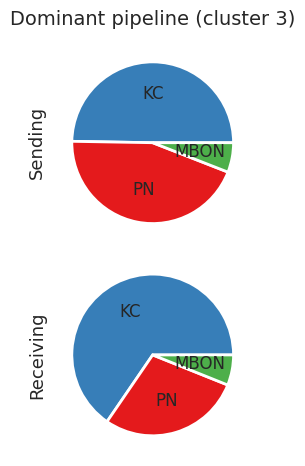

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpecFromSubplotSpec

def plot_bicommunity_types_from_edges(
    df, cluster_col, cluster_ids, types, n_nodes,
    type_colors=None, titles=None, fontsize=12
):
    # types: array/Series of node types aligned with node indices 0..n_nodes-1
    types_series = pd.Series(types)

    if type_colors is None:
        cmap = plt.get_cmap("Set1")
        uniq = list(pd.unique(types_series))
        type_colors = {t: cmap(i) for i, t in enumerate(uniq)}

    if titles is None:
        titles = [f"Cluster {c}" for c in cluster_ids]

    fig, axes = plt.subplots(1, len(cluster_ids), figsize=(5*len(cluster_ids), 5))
    if len(cluster_ids) == 1:
        axes = [axes]

    for ax, c, title in zip(axes, cluster_ids, titles):
        subdf = df[df[cluster_col] == c]
        s = np.zeros(n_nodes, dtype=int)
        r = np.zeros(n_nodes, dtype=int)
        s[subdf["pre_idx"].unique()] = 1
        r[subdf["post_idx"].unique()] = 1

        types_send = types_series[s > 0].value_counts()
        types_recv = types_series[r > 0].value_counts()

        ax.set_visible(False)
        gs = GridSpecFromSubplotSpec(2, 1, subplot_spec=ax.get_subplotspec(), hspace=0.05)
        ax0 = fig.add_subplot(gs[0])
        ax1 = fig.add_subplot(gs[1])

        ax0.set_title(title, fontsize=fontsize+2)
        ax0.set_ylabel("Sending", fontsize=fontsize+1)
        ax1.set_ylabel("Receiving", fontsize=fontsize+1)

        ax0.pie(
            types_send,
            colors=[type_colors[t] for t in types_send.index],
            labels=types_send.index,
            labeldistance=0.6,
            wedgeprops={"edgecolor": "w", "linewidth": 2},
            textprops={"fontsize": fontsize, "ha": "center"},
        )
        ax1.pie(
            types_recv,
            colors=[type_colors[t] for t in types_recv.index],
            labels=types_recv.index,
            labeldistance=0.6,
            wedgeprops={"edgecolor": "w", "linewidth": 2},
            textprops={"fontsize": fontsize, "ha": "center"},
        )

    plt.tight_layout()
    return fig

# ---- Run it: show cluster 0 and its subclusters ----
n_nodes = adj.shape[0]
types = labels  # array of "PN"/"KC"/"MBON"

# If you want only the largest cluster:
fig = plot_bicommunity_types_from_edges(
    connections_roi, "edge_cluster", cluster_ids=[largest_cluster],
    types=types, n_nodes=n_nodes,
    titles=[f"Dominant pipeline (cluster {largest_cluster})"],
)
plt.show()

# If you want the hierarchical subclusters (sub dataframe must exist):
# fig = plot_bicommunity_types_from_edges(sub, "sub_cluster", cluster_ids=[0,1,2,3,4],
#     types=types, n_nodes=n_nodes, titles=[f"Pipeline subcluster {i}" for i in range(5)])
# plt.show()

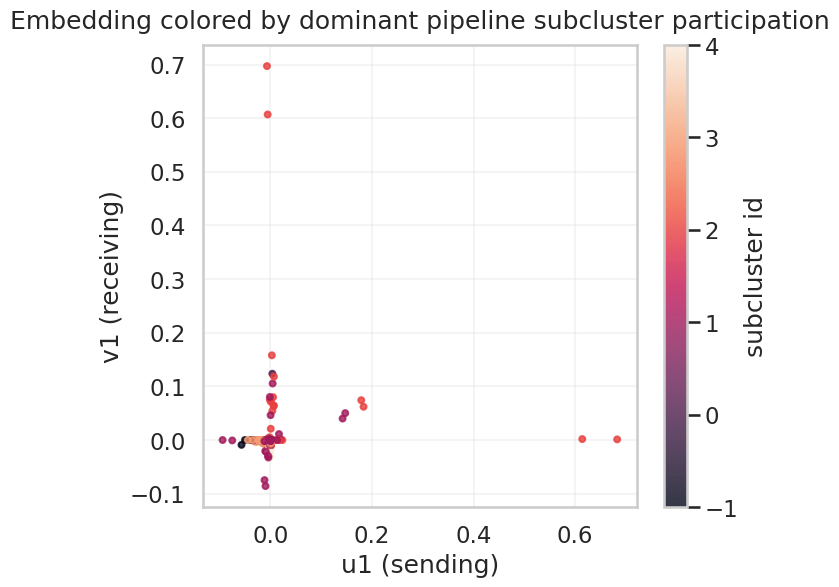

In [57]:
import numpy as np
import matplotlib.pyplot as plt

node_sub = np.full(adj.shape[0], -1, dtype=int)
counts = [dict() for _ in range(adj.shape[0])]

for _, row in sub.iterrows():
    c = int(row["sub_cluster"])
    i = int(row["pre_idx"]); j = int(row["post_idx"])
    counts[i][c] = counts[i].get(c, 0) + 1
    counts[j][c] = counts[j].get(c, 0) + 1

for i in range(adj.shape[0]):
    if counts[i]:
        node_sub[i] = max(counts[i], key=counts[i].get)

plt.figure(figsize=(7,6))
plt.scatter(u1, v1, c=node_sub, s=18, alpha=0.8)
plt.xlabel("u1 (sending)")
plt.ylabel("v1 (receiving)")
plt.title("Embedding colored by dominant pipeline subcluster participation")
plt.grid(True, alpha=0.2)
plt.colorbar(label="subcluster id")
plt.show()


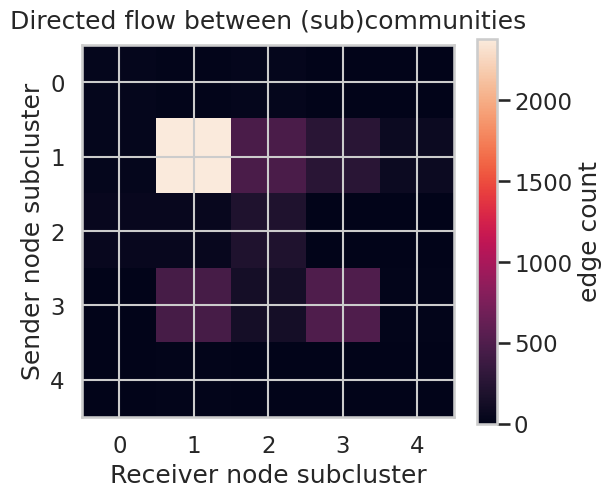

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Use subclusters within pipeline
df = sub.copy()

# Label each edge by its subcluster
K2 = df["sub_cluster"].nunique()

# Compute sender-subcluster vs receiver-subcluster counts (node-wise)
# We need node_sub labels (dominant subcluster per node) from Plot 2B:
sender_label = node_sub[df["pre_idx"].to_numpy(int)]
receiver_label = node_sub[df["post_idx"].to_numpy(int)]

flow = pd.crosstab(sender_label, receiver_label)

plt.figure(figsize=(6,5))
plt.imshow(flow.values)
plt.xticks(range(flow.shape[1]), flow.columns)
plt.yticks(range(flow.shape[0]), flow.index)
plt.xlabel("Receiver node subcluster")
plt.ylabel("Sender node subcluster")
plt.title("Directed flow between (sub)communities")
plt.colorbar(label="edge count")
plt.show()


In [59]:
import numpy as np
import pandas as pd

types = pd.Series(labels)          # length = n_nodes
node_sub_s = pd.Series(node_sub)   # length = n_nodes

# only nodes that have a subcluster assignment
mask = node_sub_s >= 0
df_nodes = pd.DataFrame({"subcluster": node_sub_s[mask].astype(int).values,
                         "type": types[mask].values})

comp = pd.crosstab(df_nodes["subcluster"], df_nodes["type"])
comp_pct = comp.div(comp.sum(axis=1), axis=0).fillna(0)

# dominant type per subcluster
dominant_type = comp_pct.idxmax(axis=1)
dominant_pct = (comp_pct.max(axis=1) * 100).round(1)

# name like: "SC3 (MBON 78%)"
subcluster_name = {
    int(k): f"SC{k} ({dominant_type.loc[k]} {dominant_pct.loc[k]}%)"
    for k in comp.index
}

print("Node-type composition per subcluster (counts):")
print(comp)
print("\nNode-type composition per subcluster (%):")
print((comp_pct*100).round(1))
print("\nSuggested labels:")
print(subcluster_name)


Node-type composition per subcluster (counts):
type         KC  MBON   PN
subcluster                
0             0     9    1
1           389    14  309
2            22    35   14
3           164     0   26
4             0     0    7

Node-type composition per subcluster (%):
type          KC  MBON     PN
subcluster                   
0            0.0  90.0   10.0
1           54.6   2.0   43.4
2           31.0  49.3   19.7
3           86.3   0.0   13.7
4            0.0   0.0  100.0

Suggested labels:
{0: 'SC0 (MBON 90.0%)', 1: 'SC1 (KC 54.6%)', 2: 'SC2 (MBON 49.3%)', 3: 'SC3 (KC 86.3%)', 4: 'SC4 (PN 100.0%)'}


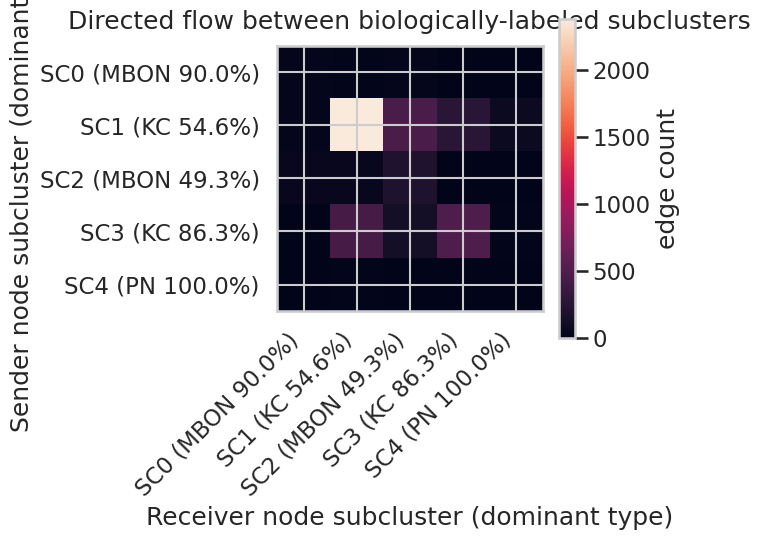

In [60]:
import matplotlib.pyplot as plt

# flow is your crosstab matrix (sender_label vs receiver_label)
# e.g., flow = pd.crosstab(sender_label, receiver_label)

xlabels = [subcluster_name.get(int(c), str(c)) for c in flow.columns]
ylabels = [subcluster_name.get(int(r), str(r)) for r in flow.index]

plt.figure(figsize=(7,6))
plt.imshow(flow.values)
plt.xticks(range(flow.shape[1]), xlabels, rotation=45, ha="right")
plt.yticks(range(flow.shape[0]), ylabels)
plt.xlabel("Receiver node subcluster (dominant type)")
plt.ylabel("Sender node subcluster (dominant type)")
plt.title("Directed flow between biologically-labeled subclusters")
plt.colorbar(label="edge count")
plt.tight_layout()
plt.show()


In [61]:
for c in sorted(sub["sub_cluster"].unique()):
    s = sub[sub["sub_cluster"] == c]
    src = (s["pre_type"].value_counts(normalize=True)*100).round(1).to_dict()
    tgt = (s["post_type"].value_counts(normalize=True)*100).round(1).to_dict()
    print(f"Subcluster {c}: edges={len(s)} | source mix={src} | target mix={tgt}")


Subcluster 0: edges=118 | source mix={'MBON': 90.7, 'PN': 9.3} | target mix={'MBON': 90.7, 'PN': 9.3}
Subcluster 1: edges=2765 | source mix={'PN': 95.3, 'KC': 2.6, 'MBON': 2.1} | target mix={'KC': 61.7, 'PN': 34.0, 'MBON': 4.4}
Subcluster 2: edges=752 | source mix={'KC': 58.9, 'PN': 22.9, 'MBON': 18.2} | target mix={'MBON': 77.8, 'PN': 22.2}
Subcluster 3: edges=970 | source mix={'PN': 100.0} | target mix={'KC': 91.2, 'PN': 8.8}
Subcluster 4: edges=98 | source mix={'PN': 100.0} | target mix={'PN': 100.0}


Subcluster 0: MBON → MBON (recurrent)
Subcluster 1: PN → KC (feedforward)
Subcluster 2: KC → MBON (feedforward)
Subcluster 3: PN → KC (feedforward)
Subcluster 4: PN → PN (recurrent)


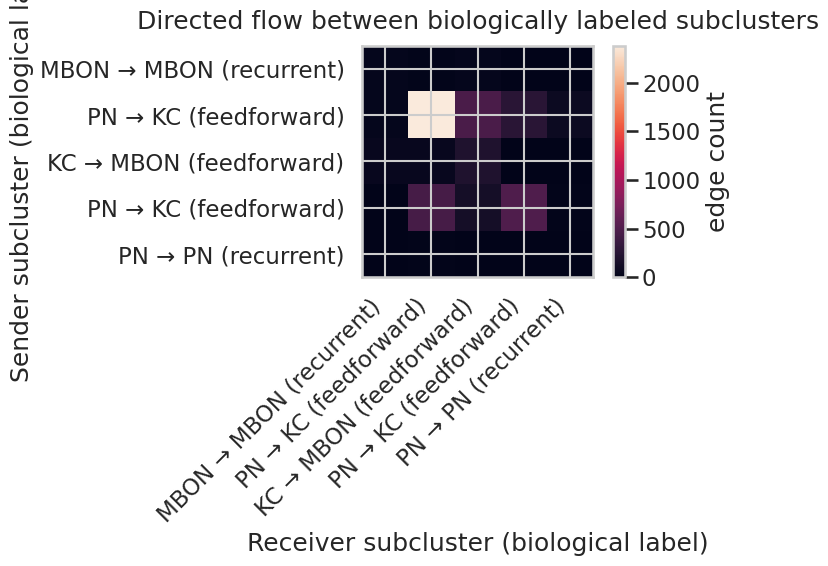

In [62]:
# --- Step 1: infer a biological label per subcluster from edge composition ---

subcluster_labels = {}

for c in sorted(sub["sub_cluster"].unique()):
    s = sub[sub["sub_cluster"] == c]

    src = s["pre_type"].value_counts(normalize=True)
    tgt = s["post_type"].value_counts(normalize=True)

    # dominant types
    src_dom, src_pct = src.idxmax(), src.max()
    tgt_dom, tgt_pct = tgt.idxmax(), tgt.max()

    # rule-based but data-driven naming
    if src_dom == "PN" and tgt_dom == "KC":
        name = "PN → KC (feedforward)"
    elif src_dom == "KC" and tgt_dom == "MBON":
        name = "KC → MBON (feedforward)"
    elif src_dom == "PN" and tgt_dom == "PN":
        name = "PN → PN (recurrent)"
    elif src_dom == "MBON" and tgt_dom == "MBON":
        name = "MBON → MBON (recurrent)"
    else:
        name = f"{src_dom} → {tgt_dom} (mixed)"

    subcluster_labels[c] = name

# Print for confirmation
for k, v in subcluster_labels.items():
    print(f"Subcluster {k}: {v}")

# --- Step 2: label sender/receiver subclusters in the heatmap ---

xlabels = [subcluster_labels.get(int(c), str(c)) for c in flow.columns]
ylabels = [subcluster_labels.get(int(r), str(r)) for r in flow.index]

plt.figure(figsize=(8,6))
plt.imshow(flow.values)
plt.xticks(range(flow.shape[1]), xlabels, rotation=45, ha="right")
plt.yticks(range(flow.shape[0]), ylabels)
plt.xlabel("Receiver subcluster (biological label)")
plt.ylabel("Sender subcluster (biological label)")
plt.title("Directed flow between biologically labeled subclusters")
plt.colorbar(label="edge count")
plt.tight_layout()
plt.show()


In [63]:
rows = []
for c in sorted(sub["sub_cluster"].unique()):
    s = sub[sub["sub_cluster"] == c]
    rows.append({
        "subcluster": c,
        "label": subcluster_labels[c],
        "edges": len(s),
        "source_mix": (s["pre_type"].value_counts(normalize=True)*100).round(1).to_dict(),
        "target_mix": (s["post_type"].value_counts(normalize=True)*100).round(1).to_dict(),
    })

summary_df = pd.DataFrame(rows)
summary_df


,subcluster,label,edges,source_mix,target_mix
0,0,MBON → MBON (recurrent),118,"{'MBON': 90.7, 'PN': 9.3}","{'MBON': 90.7, 'PN': 9.3}"
1,1,PN → KC (feedforward),2765,"{'PN': 95.3, 'KC': 2.6, 'MBON': 2.1}","{'KC': 61.7, 'PN': 34.0, 'MBON': 4.4}"
2,2,KC → MBON (feedforward),752,"{'KC': 58.9, 'PN': 22.9, 'MBON': 18.2}","{'MBON': 77.8, 'PN': 22.2}"
3,3,PN → KC (feedforward),970,{'PN': 100.0},"{'KC': 91.2, 'PN': 8.8}"
4,4,PN → PN (recurrent),98,{'PN': 100.0},{'PN': 100.0}


Using bimod_viz from /home/klrshak/work/network_Sci/banu-flywire-connectome-analysis/notebooks/bimod_viz.py


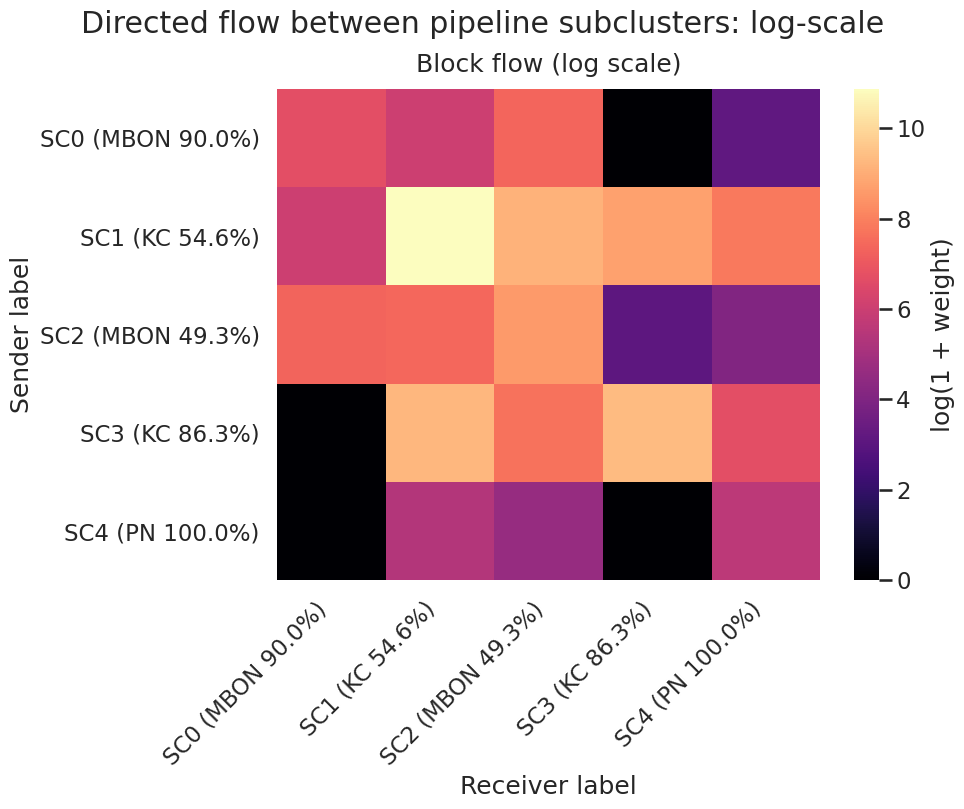

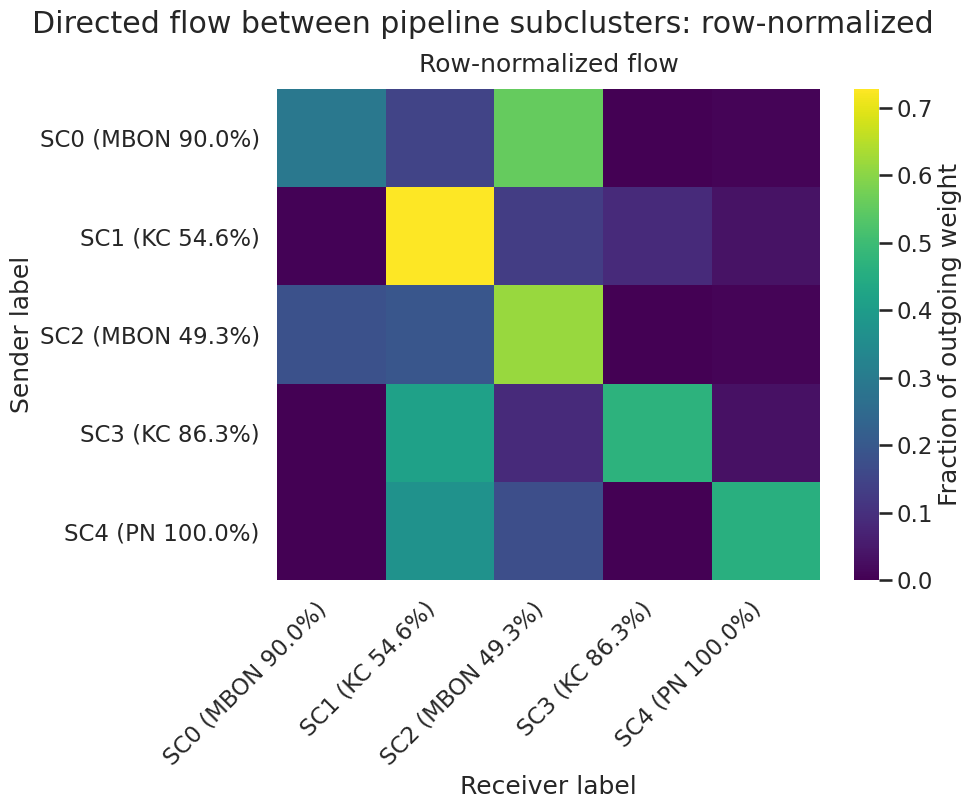

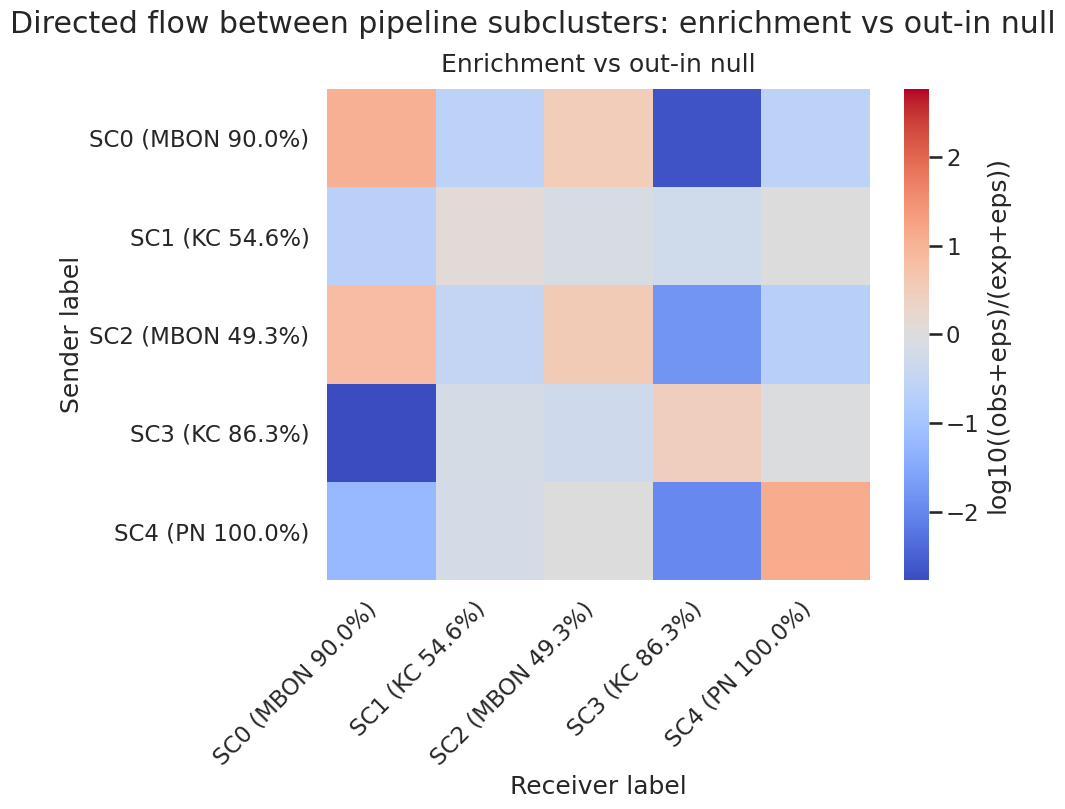

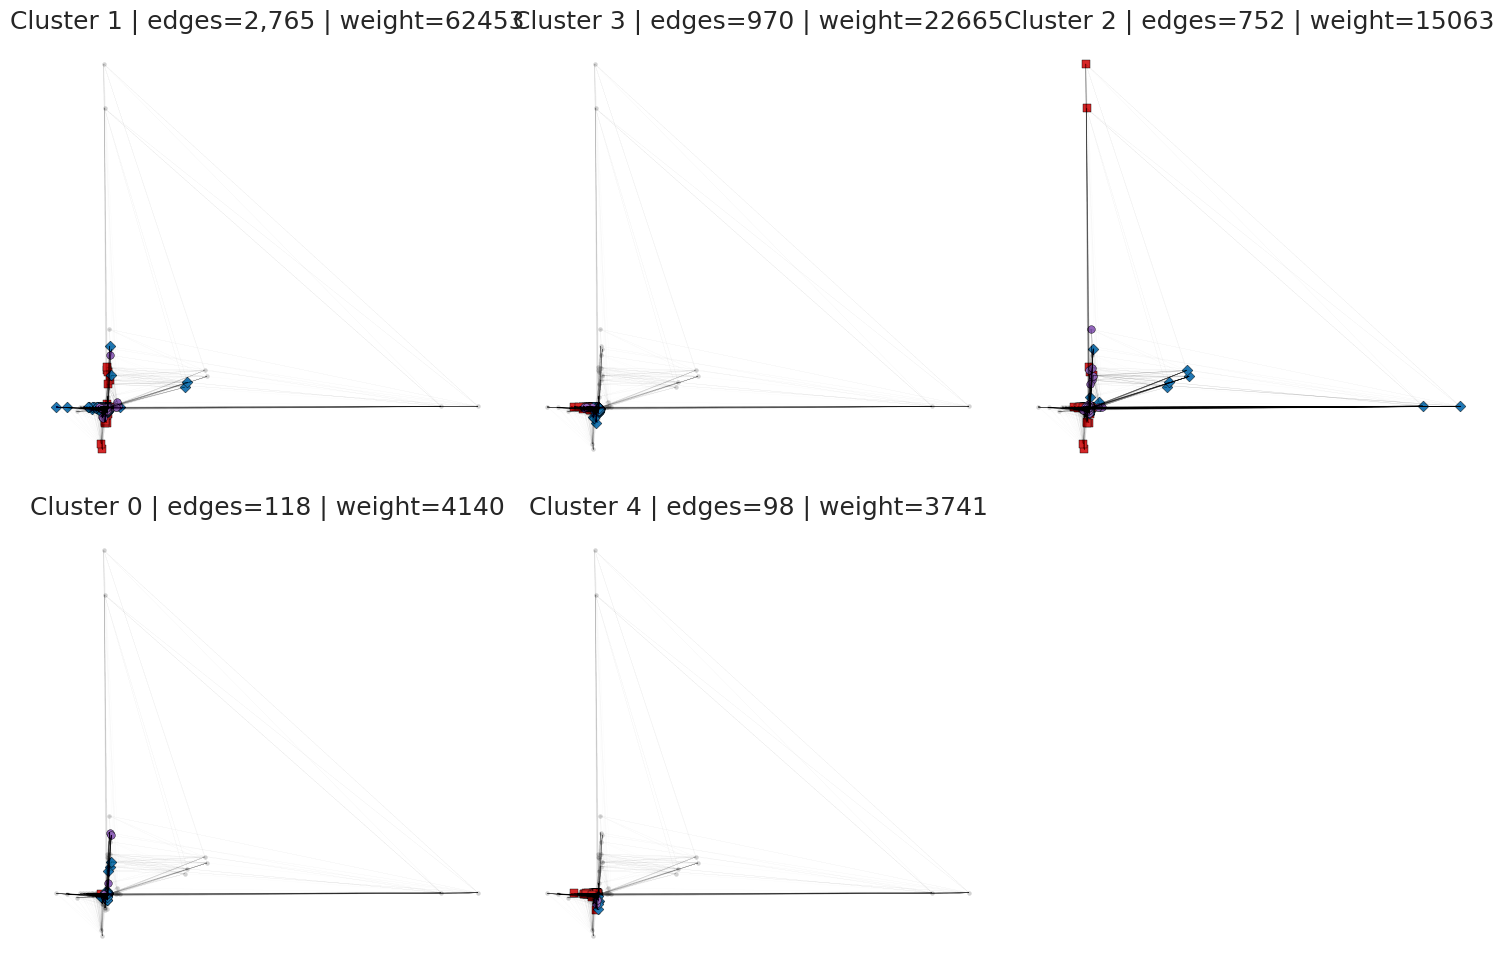

In [64]:
# Extra visualizations: pipeline *subclusters* + larger flow panels
import matplotlib.pyplot as plt

try:
    import bimod_viz as bv
except ModuleNotFoundError:
    import sys
    from pathlib import Path
    sys.path.append(str((Path.cwd() / "notebooks").resolve()))
    import bimod_viz as bv

import importlib
bv = importlib.reload(bv)
print("Using bimod_viz from", bv.__file__)

# 1) Flow between pipeline subclusters (uses `sub` + `node_sub` from earlier cells)
# Prefer SC# (dominant type %) labels if available
labels_map = globals().get("subcluster_name") or globals().get("subcluster_labels")
block = bv.block_flow_from_edges(
    sub,
    send_labels=node_sub,
    recv_labels=node_sub,
    weight_col=EDGE_WEIGHT_COL,
    drop_labels={-1},
)

fig = bv.plot_block_flow_single(block, kind="log", labels_map=labels_map, figsize=(10, 8))
fig.suptitle("Directed flow between pipeline subclusters: log-scale", y=1.02)
plt.show()

fig = bv.plot_block_flow_single(block, kind="row", labels_map=labels_map, figsize=(10, 8))
fig.suptitle("Directed flow between pipeline subclusters: row-normalized", y=1.02)
plt.show()

fig = bv.plot_block_flow_single(block, kind="enrich", labels_map=labels_map, figsize=(10, 8))
fig.suptitle("Directed flow between pipeline subclusters: enrichment vs out-in null", y=1.02)
plt.show()

# 2) Paper-style grid: each *subcluster* shown as Send/Both/Receive on the embedding
# Background edges come from the full ROI; highlighted edges come from the pipeline `sub` dataframe.
fig = bv.plot_edge_cluster_grid(
    df=sub,
    U=U,
    V=V,
    background_df=connections_roi,
    cluster_col="sub_cluster",
    weight_col=EDGE_WEIGHT_COL,
    vector_id=0,
    max_clusters=None,
    ncols=3,
    background_edges=8000,
    max_edges_per_cluster=2000,
    random_state=0,
)
plt.show()


We did not give bimodularity the idea of communities; we only gave it a place to look.
The communities emerged because the directed edge statistics are not random.
If PN/KC/MBON neurons were wired randomly among themselves, would bimodularity still find a dominant PN-sending / KC-receiving pipeline? No. 
The structure is coming from the biology encoded in the edges.

for the methods section:
Subgraph selection and validity of bimodularity analysis.
To focus on a biologically coherent subsystem while avoiding dilution of directed structure, we restricted the analysis to neurons annotated as projection neurons (PNs), Kenyon cells (KCs), and mushroom body output neurons (MBONs). This restriction was applied only at the level of node selection, all directed synaptic connections among these neurons were retained, including recurrent and feedback edges (e.g., PN→PN, KC→KC, MBON→MBON). No assumptions were made regarding the number, identity, or direction of communities.

Bimodularity was then applied to this induced subgraph using a degree-preserving out–in null model. Directed communities emerged solely from statistical deviations of observed edge patterns from the null expectation. In particular, a dominant directed bicommunity was identified whose sending side was enriched in PNs and whose receiving side was enriched in KCs and MBONs. Reapplying the same bimodularity-based edge clustering within this dominant bicommunity revealed a hierarchical decomposition into upstream PN→KC and downstream KC→MBON substructures.

Thus, the detected communities were not imposed by anatomical labels or directional constraints, but instead arose from the intrinsic directed connectivity structure of the circuit relative to the null model.

biomodularity then comes in to ask:
Are there sets of nodes that, as SENDERS,
connect to sets of nodes that, as RECEIVERS,
more than expected by chance?

## Pipeline-focused comparison (same pipeline edges for all methods)


In [67]:
# Helper functions for pipeline-focused comparison

PIPELINE_FORCE_K = 5
PIPELINE_FORCE_K_METHODS = {"louvain", "greedy"}
PIPELINE_OTHER_LABEL = "Other"

def build_pipeline_edges(connections_df, edge_cluster_col="edge_cluster", weight_col=EDGE_WEIGHT_COL):
    if "largest_cluster" in globals():
        largest_edge_cluster_id = int(largest_cluster)
    else:
        largest_edge_cluster_id = int(connections_df[edge_cluster_col].value_counts().idxmax())

    pipeline_edges_df = connections_df[connections_df[edge_cluster_col] == largest_edge_cluster_id].copy()

    pipeline_nodes = sorted(set(pipeline_edges_df["pre_idx"]) | set(pipeline_edges_df["post_idx"]))
    pipeline_node_to_local = {nid: i for i, nid in enumerate(pipeline_nodes)}

    pipeline_edges_df["pre_p"] = pipeline_edges_df["pre_idx"].map(pipeline_node_to_local)
    pipeline_edges_df["post_p"] = pipeline_edges_df["post_idx"].map(pipeline_node_to_local)

    p = len(pipeline_nodes)
    A_p = np.zeros((p, p), dtype=float)
    for row in pipeline_edges_df.itertuples(index=False):
        A_p[int(row.pre_p), int(row.post_p)] += float(getattr(row, weight_col))

    G_p = nx.DiGraph()
    G_p.add_nodes_from(range(p))
    for row in pipeline_edges_df.itertuples(index=False):
        u = int(row.pre_p)
        v = int(row.post_p)
        w = float(getattr(row, weight_col))
        if G_p.has_edge(u, v):
            G_p[u][v][weight_col] += w
        else:
            G_p.add_edge(u, v, **{weight_col: w})

    return pipeline_edges_df, pipeline_nodes, pipeline_node_to_local, A_p, G_p, largest_edge_cluster_id


def restrict_partition_to_pipeline(communities, pipeline_nodes_set, pipeline_node_to_local):
    restricted = []
    for comm in communities:
        comm_p = {n for n in comm if n in pipeline_nodes_set}
        if comm_p:
            restricted.append(comm_p)
    restricted = sorted(restricted, key=lambda s: (-len(s), min(s)))

    node_comm = np.full(len(pipeline_node_to_local), -1, dtype=int)
    for cid, comm in enumerate(restricted):
        for node in comm:
            node_comm[pipeline_node_to_local[node]] = cid
    return restricted, node_comm


def collapse_partition_to_k(node_comm, k, other_label="Other"):
    labels = [cid for cid in np.unique(node_comm) if cid >= 0]
    sizes = {cid: int((node_comm == cid).sum()) for cid in labels}

    if k is None:
        return node_comm.copy(), None, None
    if k <= 1:
        new = np.full_like(node_comm, -1)
        new[node_comm >= 0] = 0
        return new, {0: other_label}, [0]

    if len(labels) <= k:
        comm_order = sorted(labels, key=lambda c: (-sizes[c], c))
        mapping = {cid: i for i, cid in enumerate(comm_order)}
        new = np.full_like(node_comm, -1)
        for i, cid in enumerate(node_comm):
            if cid >= 0:
                new[i] = mapping[cid]
        return new, None, list(range(len(comm_order)))

    keep_ids = sorted(labels, key=lambda c: (-sizes[c], c))[: k - 1]
    mapping = {cid: i for i, cid in enumerate(keep_ids)}
    other_id = len(keep_ids)

    new = np.full_like(node_comm, -1)
    for i, cid in enumerate(node_comm):
        if cid >= 0:
            new[i] = mapping.get(cid, other_id)

    comm_order = list(range(len(keep_ids))) + [other_id]
    label_overrides = {other_id: other_label}
    return new, label_overrides, comm_order


def compute_weighted_type_mix(edges_df, node_types, idx_col, weight_col=EDGE_WEIGHT_COL, type_order=None):
    if type_order is None:
        type_order = ["PN", "KC", "MBON", "Other"]
    node_types = np.asarray(node_types)
    types = node_types[edges_df[idx_col].to_numpy(int)]
    weights = edges_df[weight_col].to_numpy(float)
    mix = (
        pd.DataFrame({"type": types, "weight": weights})
        .groupby("type")["weight"]
        .sum()
        .reindex(type_order, fill_value=0.0)
    )
    return mix


def flow_matrix_from_edges(edges_df, node_comm, comm_order, pre_col="pre_p", post_col="post_p", weight_col=EDGE_WEIGHT_COL):
    comm_to_idx = {cid: i for i, cid in enumerate(comm_order)}
    F = np.zeros((len(comm_order), len(comm_order)), dtype=float)
    pre = edges_df[pre_col].to_numpy(int)
    post = edges_df[post_col].to_numpy(int)
    weights = edges_df[weight_col].to_numpy(float)
    for u, v, w in zip(pre, post, weights):
        cu = comm_to_idx.get(node_comm[u])
        cv = comm_to_idx.get(node_comm[v])
        if cu is None or cv is None:
            continue
        F[cu, cv] += w
    return F


def community_labels_from_types(
    node_comm,
    node_types,
    type_order=None,
    prefix="SC",
    label_overrides=None,
    comm_order=None,
):
    if type_order is None:
        type_order = ["PN", "KC", "MBON", "Other"]
    if comm_order is None:
        comm_ids = [cid for cid in np.unique(node_comm) if cid >= 0]
        sizes = {cid: int((node_comm == cid).sum()) for cid in comm_ids}
        comm_order = sorted(comm_ids, key=lambda c: (-sizes[c], c))

    labels = []
    for cid in comm_order:
        if label_overrides and cid in label_overrides:
            labels.append(label_overrides[cid])
            continue
        idx = np.where(node_comm == cid)[0]
        counts = pd.Series(node_types[idx]).value_counts().reindex(type_order, fill_value=0)
        dom_type = counts.idxmax()
        dom_pct = 100 * counts.max() / counts.sum() if counts.sum() else 0.0
        labels.append(f"{prefix}{cid} ({dom_type} {dom_pct:.1f}%)")
    return labels, comm_order


def plot_pipeline_pies(edges_df, node_types, method, weight_col=EDGE_WEIGHT_COL):
    type_order = ["PN", "KC", "MBON", "Other"]
    sending_mix = compute_weighted_type_mix(edges_df, node_types, "pre_p", weight_col, type_order)
    receiving_mix = compute_weighted_type_mix(edges_df, node_types, "post_p", weight_col, type_order)

    fig, axes = plt.subplots(2, 1, figsize=(5, 8))
    axes[0].pie(sending_mix.values, labels=sending_mix.index, autopct="%1.1f%%", startangle=90)
    axes[0].set_title("Sending")
    axes[1].pie(receiving_mix.values, labels=receiving_mix.index, autopct="%1.1f%%", startangle=90)
    axes[1].set_title("Receiving")
    fig.suptitle(f"Dominant pipeline ({method})")
    plt.tight_layout()
    plt.show()


def plot_flow_heatmaps(method, F, labels, cmap="viridis"):
    row_sums = F.sum(axis=1, keepdims=True)
    flow_row = np.divide(F, row_sums, out=np.zeros_like(F), where=row_sums != 0)
    flows = {
        "raw": F,
        "log": np.log1p(F),
        "row": flow_row,
    }
    titles = {
        "raw": "Raw weights",
        "log": f"Log1p({EDGE_WEIGHT_COL})",
        "row": "Row-normalized",
    }

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (key, mat) in zip(axes, flows.items()):
        im = ax.imshow(mat, cmap=cmap)
        ax.set_xticks(range(len(labels)))
        ax.set_yticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_yticklabels(labels)
        ax.set_title(titles[key])
        cbar_label = EDGE_WEIGHT_COL if key == "raw" else (f"log1p({EDGE_WEIGHT_COL})" if key == "log" else "fraction")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=cbar_label)
    fig.suptitle(f"Directed flow between (sub)communities ({method})")
    plt.tight_layout()
    plt.show()

    return flows


def plot_side_by_side_panels(flow_by_method, labels_by_method, method_order, view, cmap="viridis"):
    vmax = max(flow_by_method[m][view].max() for m in method_order) if view != "row" else 1.0
    cbar_label = EDGE_WEIGHT_COL if view == "raw" else (f"log1p({EDGE_WEIGHT_COL})" if view == "log" else "fraction")

    fig, axes = plt.subplots(1, len(method_order), figsize=(20, 6))
    if len(method_order) == 1:
        axes = [axes]

    for ax, method in zip(axes, method_order):
        mat = flow_by_method[method][view]
        labels = labels_by_method[method]
        im = ax.imshow(mat, cmap=cmap, vmin=0, vmax=vmax)
        ax.set_xticks(range(len(labels)))
        ax.set_yticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=16)
        ax.set_yticklabels(labels, fontsize=16)
        ax.set_title(f"{method} (k={len(labels)})")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=cbar_label)

    fig.suptitle(f"Pipeline flow comparison ({view})", y=1.02)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# Step A: build pipeline subgraph once (largest edge_cluster)
(
    pipeline_edges_df,
    pipeline_nodes,
    pipeline_node_to_local,
    A_p,
    G_p,
    largest_edge_cluster_id,
) = build_pipeline_edges(connections_roi, edge_cluster_col="edge_cluster", weight_col=EDGE_WEIGHT_COL)

# If subclusters already computed, prefer them for bimodularity pipeline nodes
if "sub" in globals() and isinstance(sub, pd.DataFrame) and "sub_cluster" in sub.columns:
    if "edge_cluster" in sub.columns and sub["edge_cluster"].nunique() == 1:
        sub_cluster_id = int(sub["edge_cluster"].iloc[0])
        if sub_cluster_id != int(largest_edge_cluster_id):
            print("Warning: sub edge_cluster does not match largest_edge_cluster_id; using sub as-is.")
    pipeline_edges_df = sub.copy()
    pipeline_nodes = sorted(set(pipeline_edges_df["pre_idx"]) | set(pipeline_edges_df["post_idx"]))
    pipeline_node_to_local = {nid: i for i, nid in enumerate(pipeline_nodes)}
    pipeline_edges_df["pre_p"] = pipeline_edges_df["pre_idx"].map(pipeline_node_to_local)
    pipeline_edges_df["post_p"] = pipeline_edges_df["post_idx"].map(pipeline_node_to_local)

    p = len(pipeline_nodes)
    A_p = np.zeros((p, p), dtype=float)
    for row in pipeline_edges_df.itertuples(index=False):
        A_p[int(row.pre_p), int(row.post_p)] += float(getattr(row, EDGE_WEIGHT_COL))

    G_p = nx.DiGraph()
    G_p.add_nodes_from(range(p))
    for row in pipeline_edges_df.itertuples(index=False):
        u = int(row.pre_p)
        v = int(row.post_p)
        w = float(getattr(row, EDGE_WEIGHT_COL))
        if G_p.has_edge(u, v):
            G_p[u][v][EDGE_WEIGHT_COL] += w
        else:
            G_p.add_edge(u, v, **{EDGE_WEIGHT_COL: w})

p = len(pipeline_nodes)
print(f"Pipeline cluster id: {largest_edge_cluster_id} | nodes: {p} | edges: {len(pipeline_edges_df)}")

pipeline_nodes_set = set(pipeline_nodes)
pipeline_node_types = labels[pipeline_nodes]

# Step B: ensure global ROI communities exist, then restrict to pipeline nodes
if "G_roi" in globals():
    G_roi = G_roi
elif "G" in globals():
    G_roi = G
else:
    G_roi = nx.DiGraph()
    G_roi.add_nodes_from(range(adj.shape[0]))
    for row in connections_roi.itertuples(index=False):
        u = int(row.pre_idx)
        v = int(row.post_idx)
        w = float(getattr(row, EDGE_WEIGHT_COL))
        if G_roi.has_edge(u, v):
            G_roi[u][v][EDGE_WEIGHT_COL] += w
        else:
            G_roi.add_edge(u, v, **{EDGE_WEIGHT_COL: w})

if "comms_louvain" in globals():
    communities_louvain = comms_louvain
elif "communities_louvain" in globals():
    communities_louvain = communities_louvain
else:
    communities_louvain = nx.community.louvain_communities(G_roi, weight=EDGE_WEIGHT_COL, seed=0)

if "comms_greedy" in globals():
    communities_greedy = comms_greedy
elif "communities_greedy" in globals():
    communities_greedy = communities_greedy
else:
    communities_greedy = list(nx.community.greedy_modularity_communities(G_roi, weight=EDGE_WEIGHT_COL))

comms_louvain_p, node_comm_louvain_p = restrict_partition_to_pipeline(
    communities_louvain, pipeline_nodes_set, pipeline_node_to_local
)
comms_greedy_p, node_comm_greedy_p = restrict_partition_to_pipeline(
    communities_greedy, pipeline_nodes_set, pipeline_node_to_local
)

# Bimodularity pipeline node subclusters
if "node_sub" in globals():
    node_comm_bimod_p = np.asarray(node_sub)[pipeline_nodes]
elif "sub" in globals() and isinstance(sub, pd.DataFrame) and "sub_cluster" in sub.columns:
    counts = [dict() for _ in range(p)]
    for row in pipeline_edges_df.itertuples(index=False):
        c = int(row.sub_cluster)
        i = int(row.pre_p)
        j = int(row.post_p)
        counts[i][c] = counts[i].get(c, 0) + 1
        counts[j][c] = counts[j].get(c, 0) + 1
    node_comm_bimod_p = np.full(p, -1, dtype=int)
    for i, ctr in enumerate(counts):
        if ctr:
            node_comm_bimod_p[i] = max(ctr.items(), key=lambda kv: (kv[1], -kv[0]))[0]
else:
    raise ValueError("No bimodularity subcluster assignment found (node_sub or sub['sub_cluster']).")


Pipeline cluster id: 3 | nodes: 990 | edges: 4703



=== bimod ===


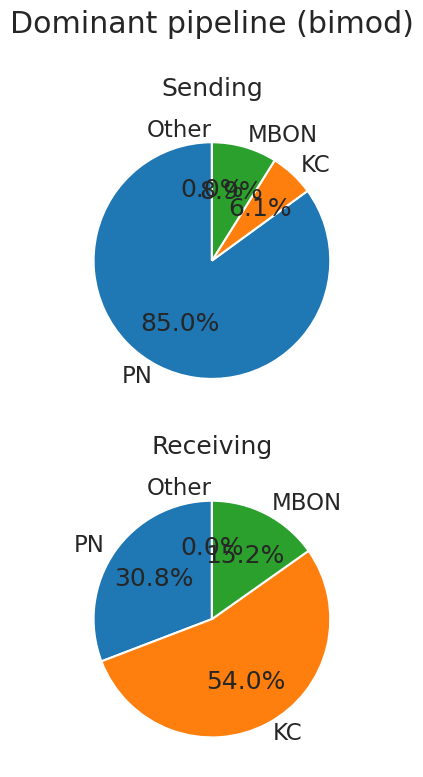

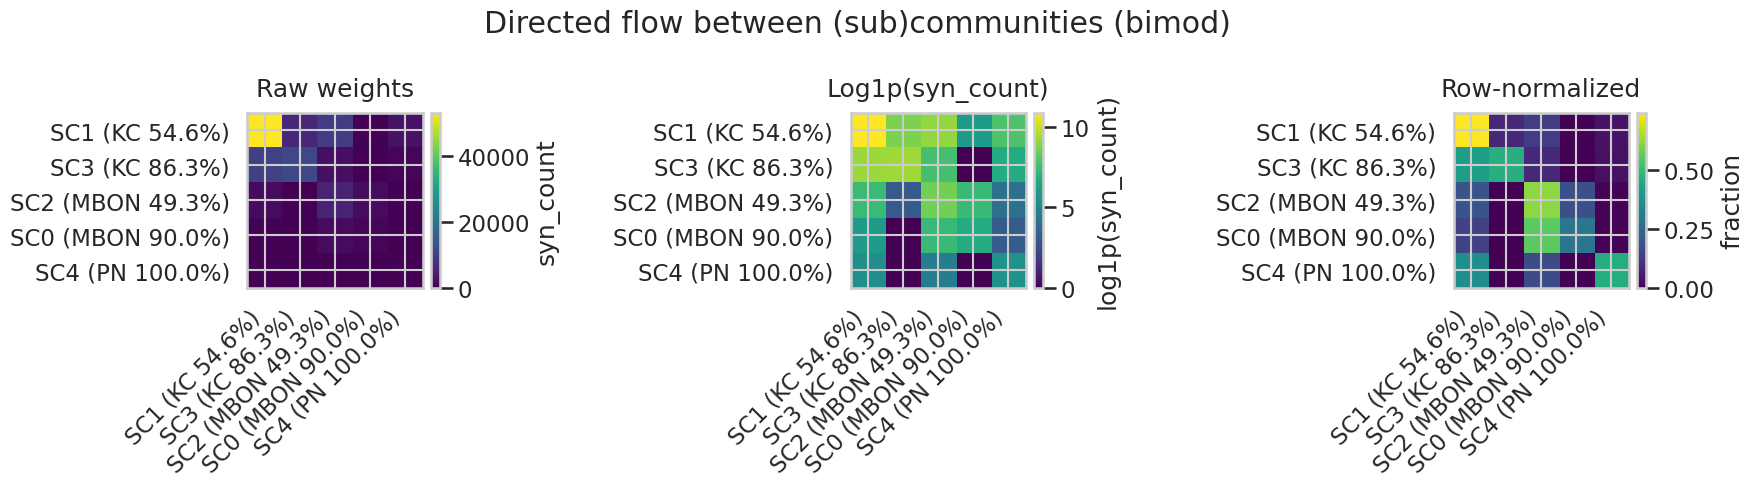

bimod type->type flow (PN/KC/MBON)


,PN,KC,MBON
PN,33057.0,58161.0,665.0
KC,0.0,166.0,6394.0
MBON,244.0,0.0,9375.0


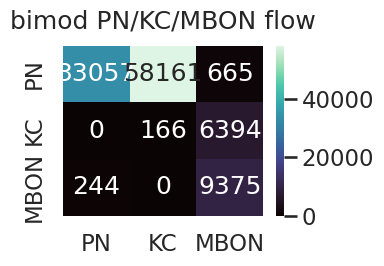


=== louvain ===


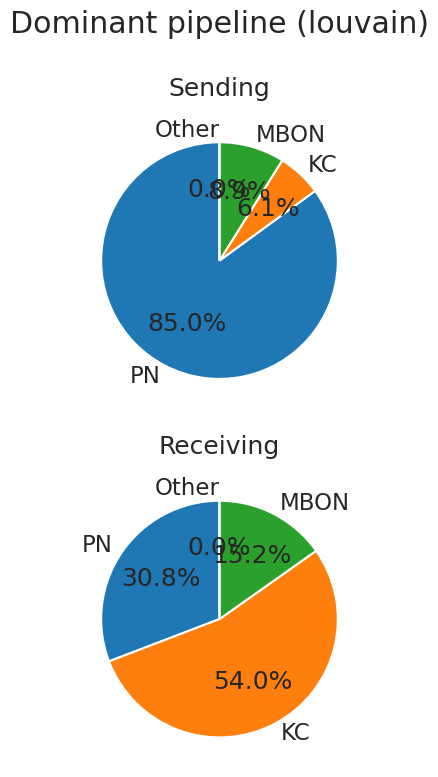

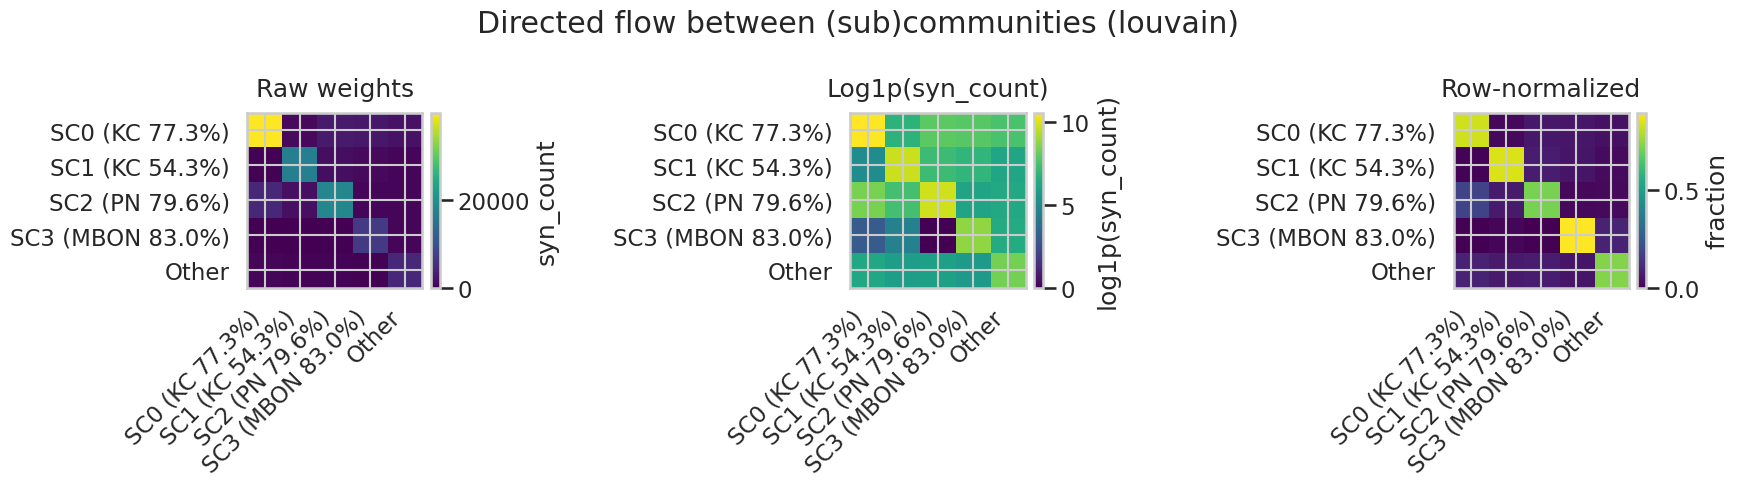

louvain type->type flow (PN/KC/MBON)


,PN,KC,MBON
PN,33057.0,58161.0,665.0
KC,0.0,166.0,6394.0
MBON,244.0,0.0,9375.0


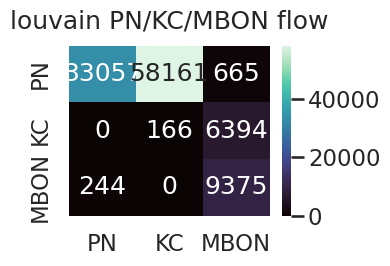


=== greedy ===


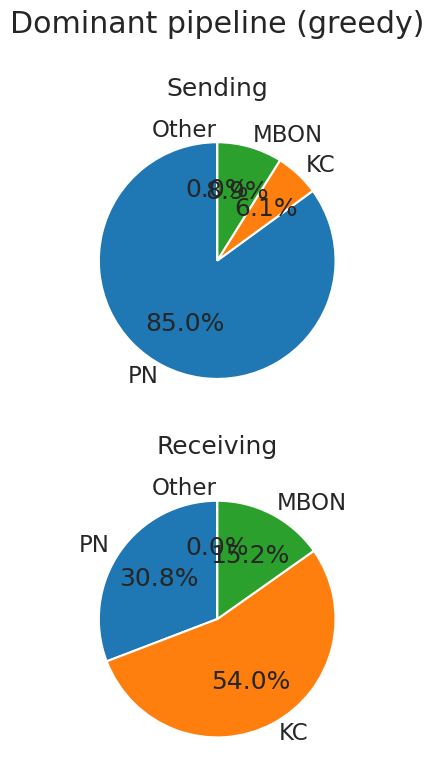

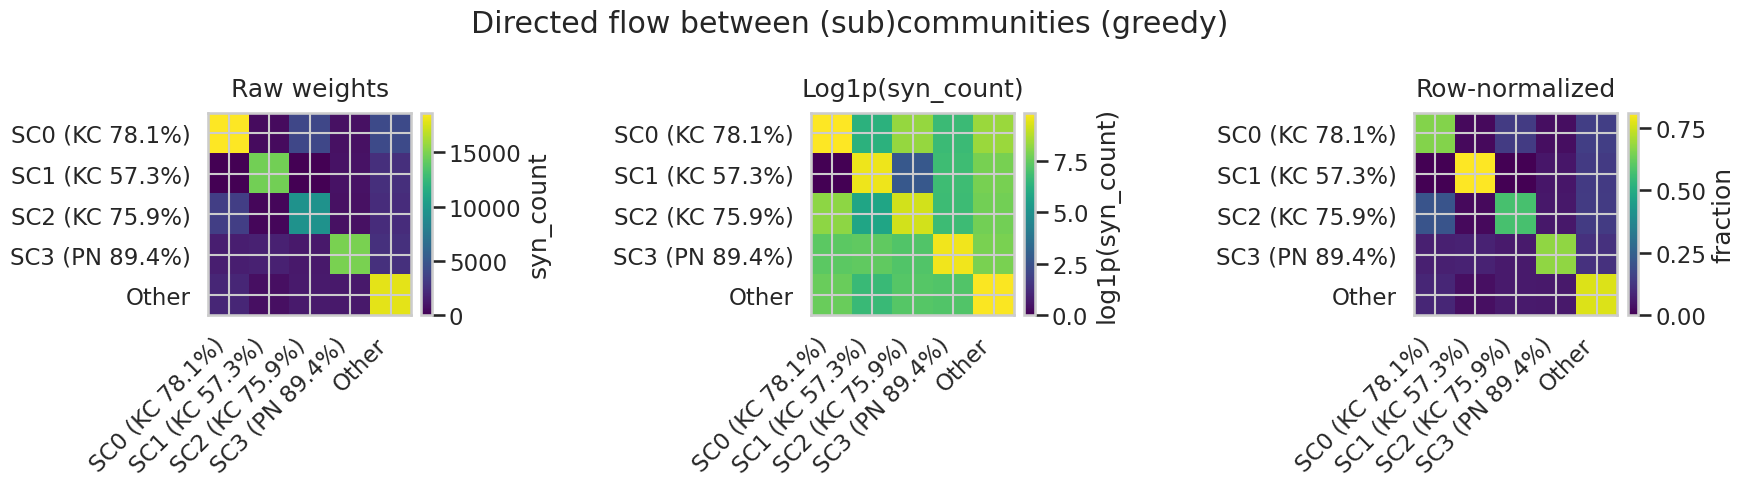

greedy type->type flow (PN/KC/MBON)


,PN,KC,MBON
PN,33057.0,58161.0,665.0
KC,0.0,166.0,6394.0
MBON,244.0,0.0,9375.0


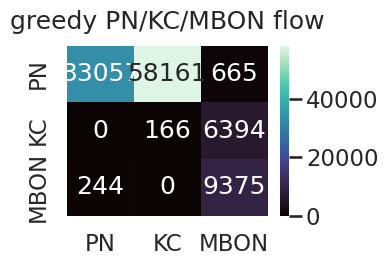

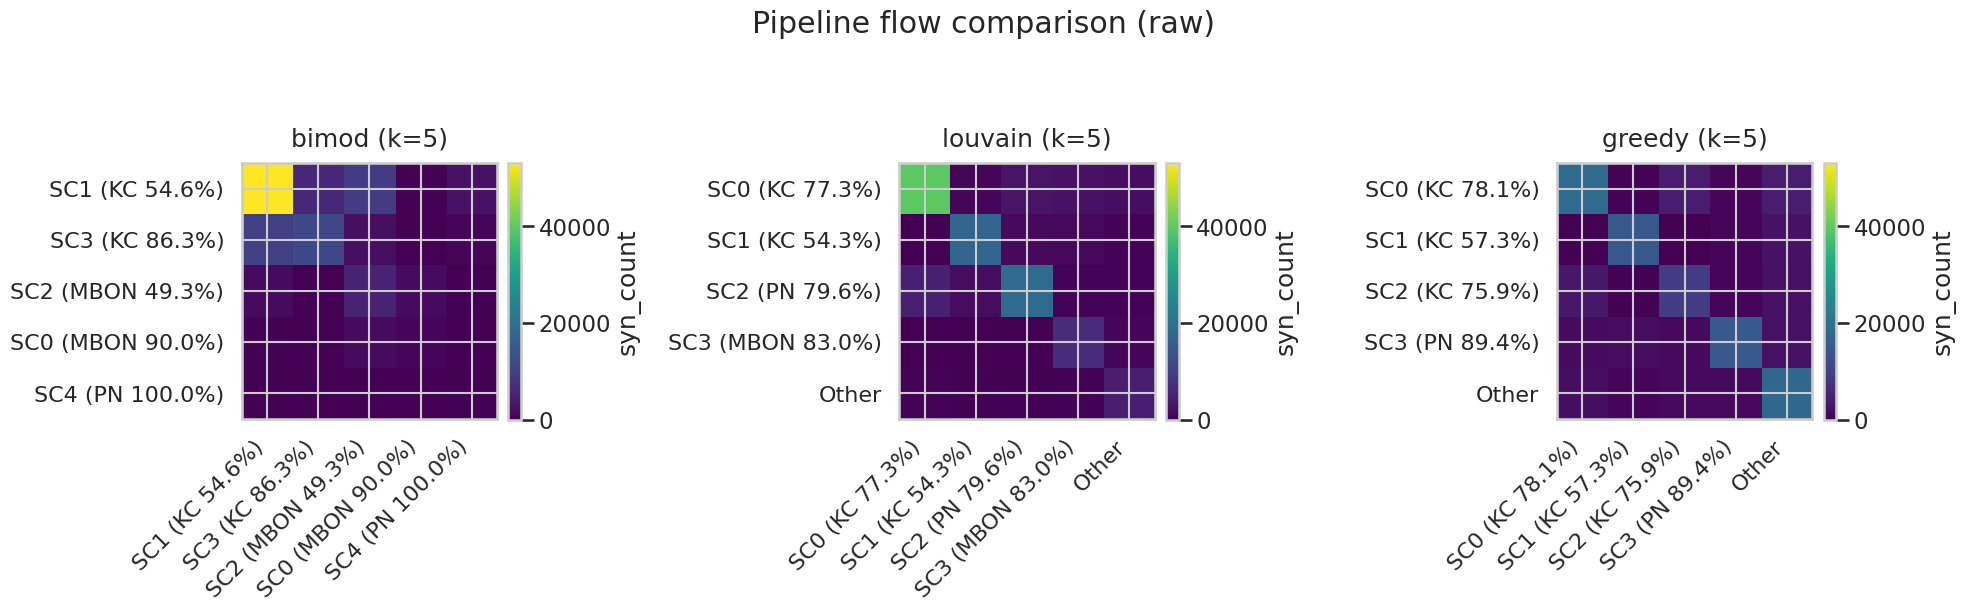

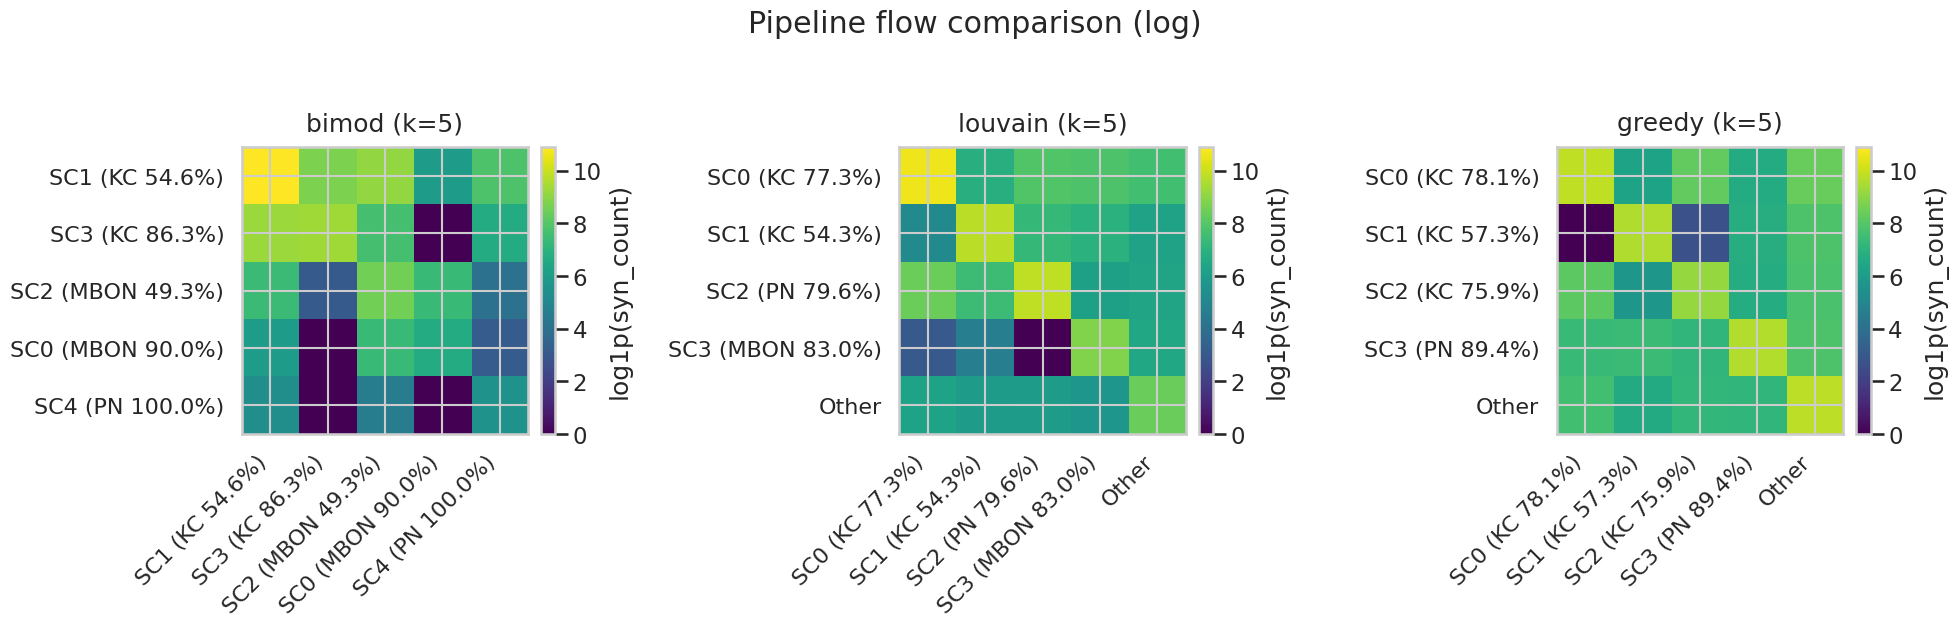

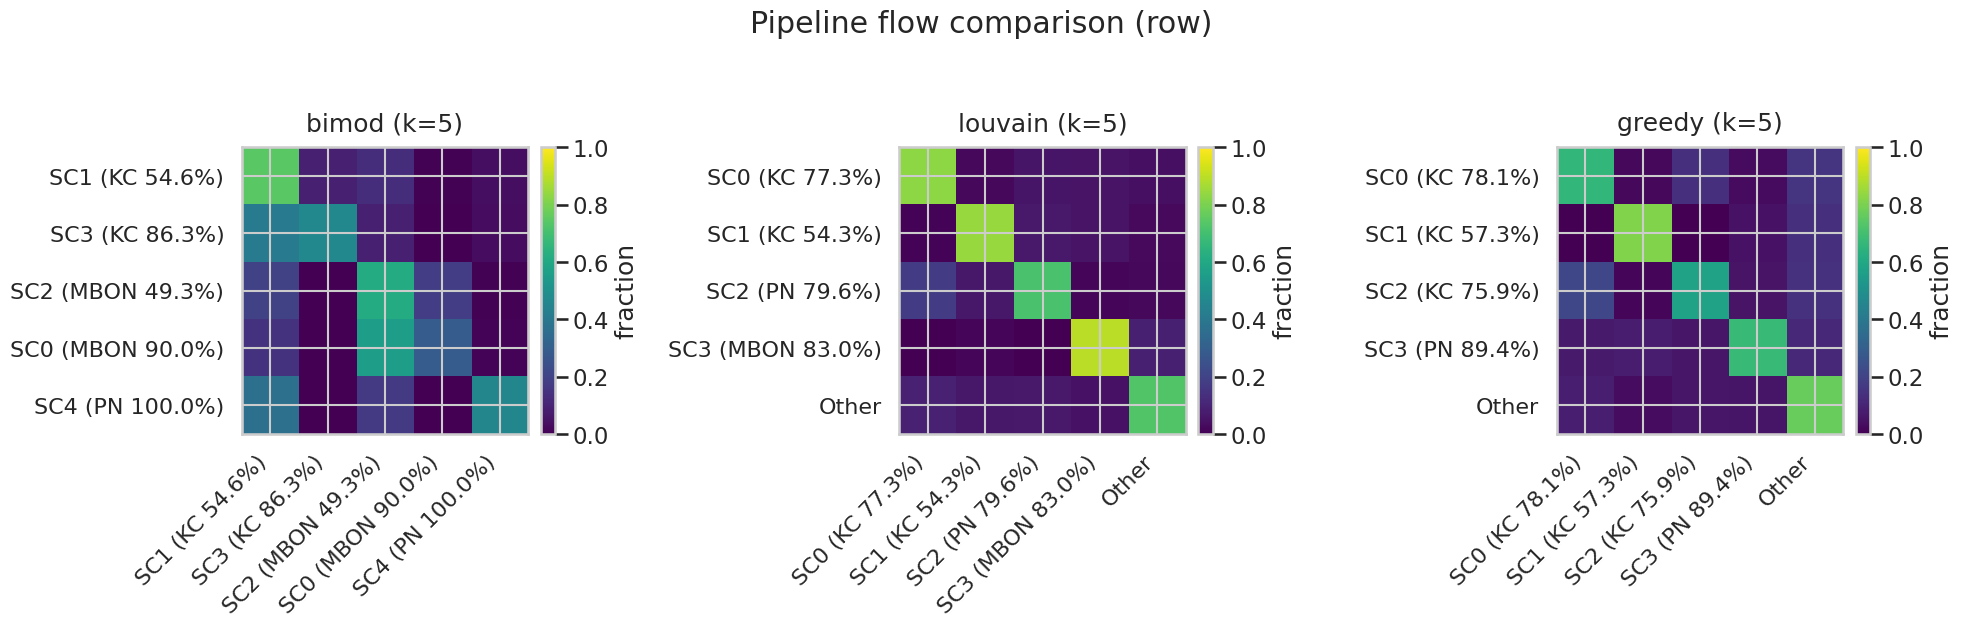

In [68]:
# Step C: pipeline visuals for bimod, louvain, greedy
methods = {
    "bimod": node_comm_bimod_p,
    "louvain": node_comm_louvain_p,
    "greedy": node_comm_greedy_p,
}

flow_by_method = {}
labels_by_method = {}

for method, node_comm in methods.items():
    print(f"\n=== {method} ===")
    plot_pipeline_pies(pipeline_edges_df, pipeline_node_types, method)

    node_comm_use = node_comm
    label_overrides = None
    comm_order = None
    if PIPELINE_FORCE_K is not None and method in PIPELINE_FORCE_K_METHODS:
        node_comm_use, label_overrides, comm_order = collapse_partition_to_k(
            node_comm_use,
            PIPELINE_FORCE_K,
            other_label=PIPELINE_OTHER_LABEL,
        )

    labels_comm, comm_order = community_labels_from_types(
        node_comm_use,
        pipeline_node_types,
        label_overrides=label_overrides,
        comm_order=comm_order,
    )
    labels_by_method[method] = labels_comm

    F = flow_matrix_from_edges(pipeline_edges_df, node_comm_use, comm_order)
    flow_by_method[method] = plot_flow_heatmaps(method, F, labels_comm)

    # Type->type flow summary (PN/KC/MBON) for pipeline edges
    type_order = ["PN", "KC", "MBON"]
    type_to_idx = {t: i for i, t in enumerate(type_order)}
    type_flow = np.zeros((len(type_order), len(type_order)), dtype=float)
    pre_p = pipeline_edges_df["pre_p"].to_numpy(int)
    post_p = pipeline_edges_df["post_p"].to_numpy(int)
    weights = pipeline_edges_df[EDGE_WEIGHT_COL].to_numpy(float)
    for u, v, w in zip(pre_p, post_p, weights):
        if node_comm_use[u] < 0 or node_comm_use[v] < 0:
            continue
        tu = pipeline_node_types[u]
        tv = pipeline_node_types[v]
        if tu in type_to_idx and tv in type_to_idx:
            type_flow[type_to_idx[tu], type_to_idx[tv]] += w

    type_flow_df = pd.DataFrame(type_flow, index=type_order, columns=type_order)
    print(f"{method} type->type flow (PN/KC/MBON)")
    display(type_flow_df)
    plt.figure(figsize=(4, 3))
    sns.heatmap(type_flow_df, annot=True, fmt=".0f", cmap="mako")
    plt.title(f"{method} PN/KC/MBON flow")
    plt.tight_layout()
    plt.show()

# Step D: side-by-side comparison panels (raw/log/row-normalized)
method_order = ["bimod", "louvain", "greedy"]
for view in ["raw", "log", "row"]:
    plot_side_by_side_panels(flow_by_method, labels_by_method, method_order, view)
